# Field Map NN: Grid Search Analysis & Trajectory Comparison

This notebook:

1. **Grid Search Analysis** — Load all 30 trained models, compare accuracy vs architecture
2. **Trajectory Comparison** — Implement Python RK steppers (RK4, CashKarp, Euler, Parabolic) with both trilinear field and NN field, compare resulting tracks
3. **C++ Deployment** — Generate optimised C++ code for the best model

**Context**: Profiling shows field lookups consume ~76% of RK propagation cost (~0.109 µs per trilinear lookup, ~69 lookups per CashKarp track). A fast NN surrogate whose weights fit in L1 cache can eliminate cache-miss latency from the 4.5 MB grid.

**Unit note**: The field map `twodip.rtf` stores field values in **Gauss** (not Tesla). 1 T = 10,000 Gauss.

In [1]:
import json, os, sys, time, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.facecolor': 'white',
})

# Paths
PROJECT  = Path('..').resolve()
RESULTS  = PROJECT / 'trained_models'
WORKSPACE = PROJECT.parent.parent.parent   # TrackExtrapolation/
SRC_DIR  = WORKSPACE / 'src'

# Add training dir for trilinear import
sys.path.insert(0, str(PROJECT / 'training'))

print(f'Project:   {PROJECT}')
print(f'Results:   {RESULTS}')
print(f'Workspace: {WORKSPACE}')

Project:   /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/field_nn
Results:   /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/field_nn/trained_models
Workspace: /data/bfys/gscriven/TrackExtrapolation


---
## Part I: Grid Search Results

30 architectures: **5 widths** (32, 64, 128, 256, 512) × **3 depths** (1, 2, 3 hidden layers) × **2 activations** (ReLU, SiLU).

In [2]:
# Load all completed training results
rows = []
for d in sorted(RESULTS.iterdir()):
    hist_path = d / 'history.json'
    mcfg_path = d / 'model_config.json'
    if not hist_path.exists():
        continue
    with open(hist_path) as f:
        hist = json.load(f)
    with open(mcfg_path) as f:
        mcfg = json.load(f)

    fm = hist['final_metrics']
    hidden_dims = mcfg['hidden_dims']
    rows.append({
        'name':       d.name,
        'activation': mcfg['activation'],
        'depth':      len(hidden_dims),
        'width':      hidden_dims[0],
        'params':     mcfg['parameters'],
        'flops':      mcfg['flops'],
        'mae_gauss':  fm['mae_gauss'],
        'p99_gauss':  fm['p99_gauss'],
        'max_gauss':  fm['max_gauss'],
        'bx_mae':     fm.get('per_component', {}).get('Bx', {}).get('mae_gauss', np.nan),
        'by_mae':     fm.get('per_component', {}).get('By', {}).get('mae_gauss', np.nan),
        'bz_mae':     fm.get('per_component', {}).get('Bz', {}).get('mae_gauss', np.nan),
        'epochs':     hist['epochs_run'],
        'best_epoch': hist['best_epoch'],
        'train_time': hist['train_time_s'],
    })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)}/30 models')

# Weight memory in KB (float32)
df['weight_kb'] = df['params'] * 4 / 1024

df_sorted = df.sort_values('mae_gauss')
display(df_sorted[['name','activation','depth','width','params','flops','weight_kb',
                    'mae_gauss','p99_gauss','max_gauss','epochs','train_time']].reset_index(drop=True))

Loaded 30/30 models


,name,activation,depth,width,params,flops,weight_kb,mae_gauss,p99_gauss,max_gauss,epochs,train_time
0,field_nn_silu_3L_256H,silu,3,256,133379,268288,521.011719,0.499016,4.654700,14674.7584,194,2345.363020
1,field_nn_silu_3L_512H,silu,3,512,528899,1060864,2066.011719,0.507934,5.272348,11284.6360,200,2880.867795
2,field_nn_relu_2L_512H,relu,2,512,266243,531456,1040.011719,0.601250,5.196720,17397.6208,176,2518.951038
3,field_nn_relu_3L_128H,relu,3,128,33923,67456,132.511719,0.620068,4.299645,17408.0064,85,1157.392438
4,field_nn_silu_2L_128H,silu,2,128,17411,35328,68.011719,0.703519,6.881345,16987.7152,167,1995.790827
5,field_nn_silu_3L_128H,silu,3,128,33923,68608,132.511719,0.704989,4.645847,16865.4224,90,1077.583386
6,field_nn_silu_2L_64H,silu,2,64,4611,9472,18.011719,0.733342,7.105175,16991.0464,197,2483.942111
7,field_nn_silu_1L_256H,silu,1,256,1795,4096,7.011719,0.737738,5.119594,16764.4000,37,485.704309
8,field_nn_relu_3L_64H,relu,3,64,8771,17344,34.261719,0.740718,4.980514,17218.4528,173,2197.836226
9,field_nn_silu_3L_64H,silu,3,64,8771,17920,34.261719,0.747908,4.637301,17417.7552,130,1856.707371


/tmp/ipykernel_1040995/1709880650.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


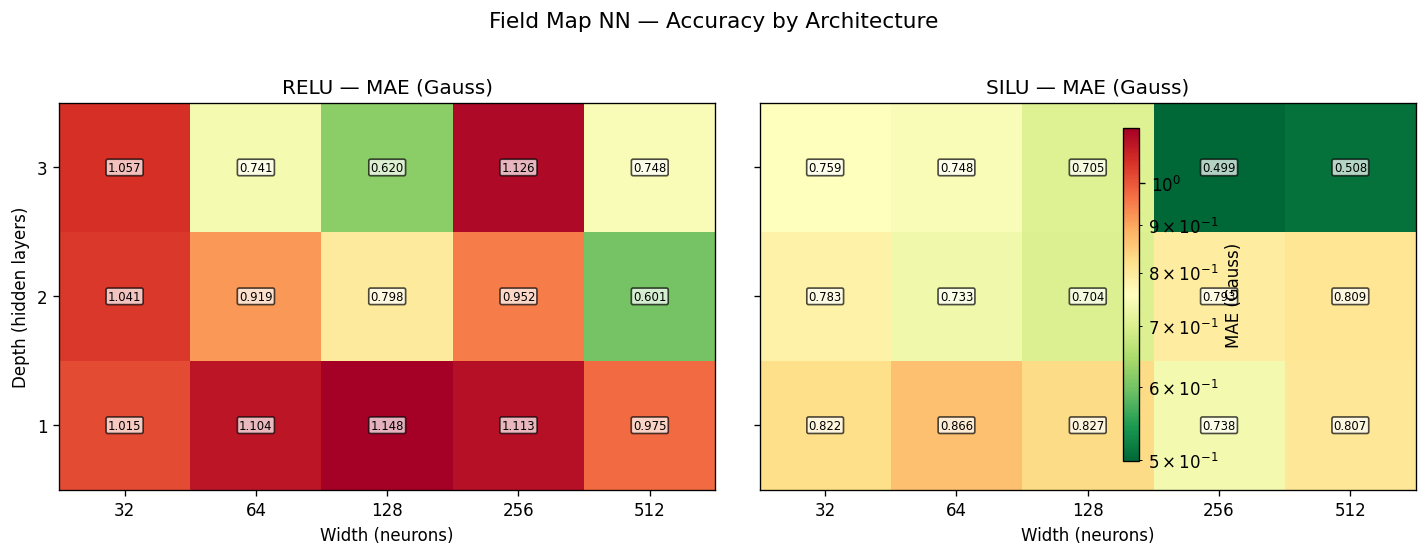

In [3]:
# Heatmaps: MAE vs (width, depth) for each activation
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

widths = sorted(df['width'].unique())
depths = sorted(df['depth'].unique())

vmin = max(0.01, df['mae_gauss'].min())
vmax = df['mae_gauss'].max()

for ax, act in zip(axes, ['relu', 'silu']):
    sub = df[df['activation'] == act]
    pivot = sub.pivot(index='depth', columns='width', values='mae_gauss')
    pivot = pivot.reindex(index=depths, columns=widths)

    im = ax.imshow(pivot.values, aspect='auto',
                   norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
                   cmap='RdYlGn_r', origin='lower')
    ax.set_xticks(range(len(widths)))
    ax.set_xticklabels(widths)
    ax.set_yticks(range(len(depths)))
    ax.set_yticklabels(depths)
    ax.set_xlabel('Width (neurons)')
    ax.set_title(f'{act.upper()} — MAE (Gauss)')

    for i in range(len(depths)):
        for j in range(len(widths)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=7, color='black',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7))

axes[0].set_ylabel('Depth (hidden layers)')
fig.colorbar(im, ax=axes, label='MAE (Gauss)', shrink=0.8)
fig.suptitle('Field Map NN — Accuracy by Architecture', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('accuracy_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

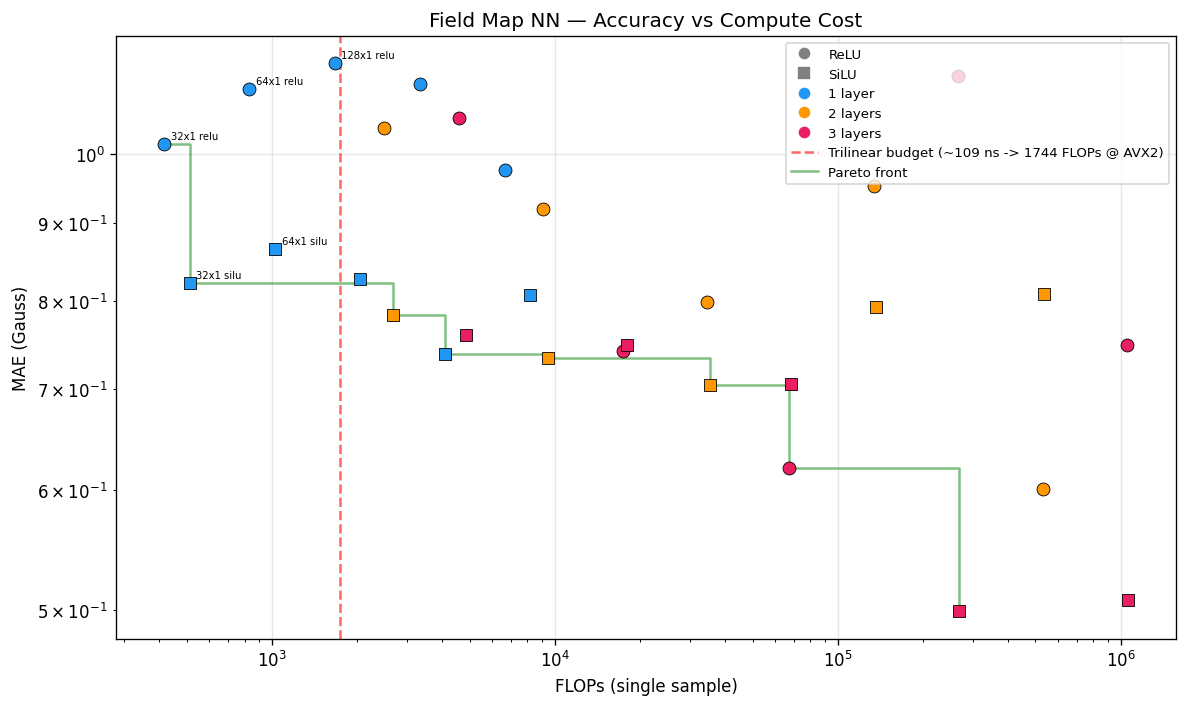

In [4]:
# Pareto frontier: MAE vs FLOPs
TRILINEAR_NS = 109  # measured from profiling

fig, ax = plt.subplots(figsize=(10, 6))

markers = {'relu': 'o', 'silu': 's'}
colours = {1: '#2196F3', 2: '#FF9800', 3: '#E91E63'}

for _, row in df.iterrows():
    ax.scatter(row['flops'], row['mae_gauss'],
              marker=markers[row['activation']],
              color=colours[row['depth']],
              s=60, edgecolors='black', linewidths=0.5, zorder=3)
    if row['flops'] < 2000:
        ax.annotate(f"{row['width']}x{row['depth']} {row['activation']}",
                    (row['flops'], row['mae_gauss']),
                    fontsize=6, ha='left', va='bottom',
                    xytext=(4, 2), textcoords='offset points')

ax.axvline(TRILINEAR_NS * 16, color='red', ls='--', alpha=0.6,
           label=f'Trilinear budget (~{TRILINEAR_NS} ns -> {TRILINEAR_NS*16} FLOPs @ AVX2)')

# Pareto front
df_pf = df.sort_values('flops')
pareto_flops, pareto_mae = [], []
best_mae = float('inf')
for _, row in df_pf.iterrows():
    if row['mae_gauss'] < best_mae:
        pareto_flops.append(row['flops'])
        pareto_mae.append(row['mae_gauss'])
        best_mae = row['mae_gauss']
ax.step(pareto_flops, pareto_mae, where='post', color='green', ls='-', alpha=0.5,
        label='Pareto front', zorder=2)

legend_elems = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='ReLU'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='SiLU'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[1], markersize=8, label='1 layer'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[2], markersize=8, label='2 layers'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=colours[3], markersize=8, label='3 layers'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=legend_elems + handles, loc='upper right', fontsize=8)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('FLOPs (single sample)'); ax.set_ylabel('MAE (Gauss)')
ax.set_title('Field Map NN — Accuracy vs Compute Cost')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pareto_accuracy_vs_flops.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Select models for trajectory comparison
SPEED_BUDGET_FLOPS = 1500

viable = df[df['flops'] <= SPEED_BUDGET_FLOPS].sort_values('mae_gauss')
best_overall = df.sort_values('mae_gauss').iloc[0]
best_viable  = viable.iloc[0]

print('=== Best overall ===')
print(f'  {best_overall["name"]}: MAE={best_overall["mae_gauss"]:.3f} G, '
      f'FLOPs={best_overall["flops"]}, {best_overall["params"]:,} params, '
      f'{best_overall["weight_kb"]:.1f} KB')

print('\n=== Best speed-viable (<=1500 FLOPs) ===')
print(f'  {best_viable["name"]}: MAE={best_viable["mae_gauss"]:.3f} G, '
      f'FLOPs={best_viable["flops"]}, {best_viable["params"]:,} params, '
      f'{best_viable["weight_kb"]:.1f} KB')

print('\n=== All speed-viable models ===')
print(viable[['name','activation','depth','width','params','flops',
              'weight_kb','mae_gauss','p99_gauss']].to_string(index=False))

=== Best overall ===
  field_nn_silu_3L_256H: MAE=0.499 G, FLOPs=268288, 133,379 params, 521.0 KB

=== Best speed-viable (<=1500 FLOPs) ===
  field_nn_silu_1L_32H: MAE=0.822 G, FLOPs=512, 227 params, 0.9 KB

=== All speed-viable models ===
                name activation  depth  width  params  flops  weight_kb  mae_gauss  p99_gauss
field_nn_silu_1L_32H       silu      1     32     227    512   0.886719   0.821658   4.757155
field_nn_silu_1L_64H       silu      1     64     451   1024   1.761719   0.865593   4.810380
field_nn_relu_1L_32H       relu      1     32     227    416   0.886719   1.015086   5.304953
field_nn_relu_1L_64H       relu      1     64     451    832   1.761719   1.103598   5.408538


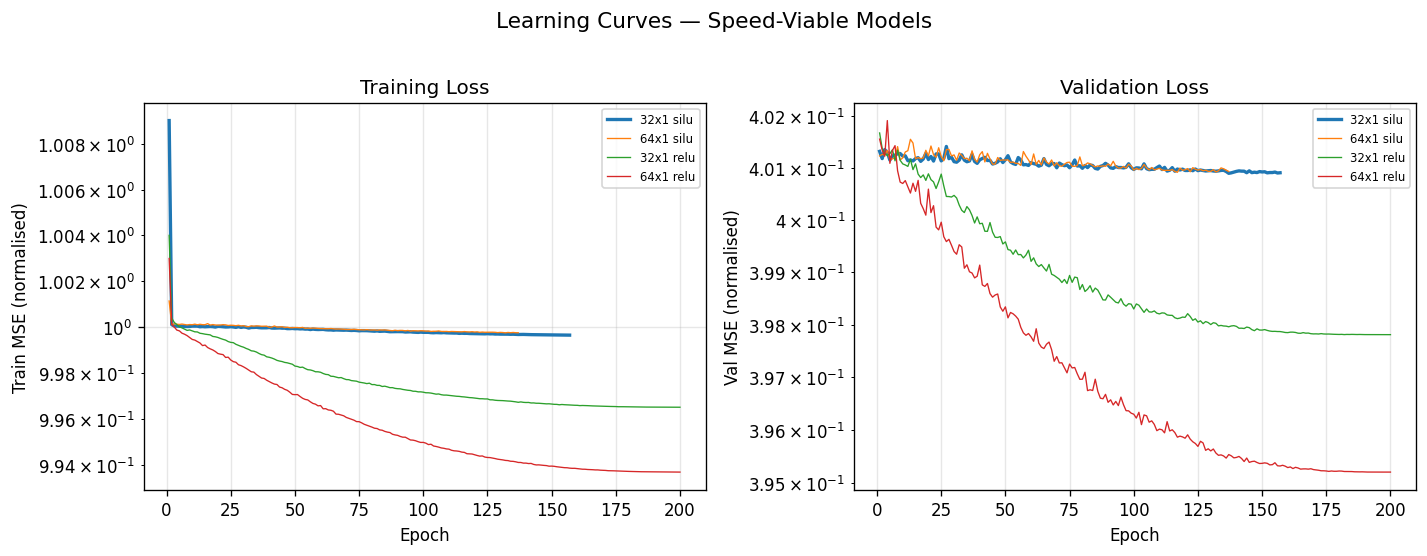

In [6]:
# Learning curves for speed-viable models
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for _, row in viable.iterrows():
    hist_path = RESULTS / row['name'] / 'history.json'
    with open(hist_path) as f:
        hist = json.load(f)['history']

    label = f"{row['width']}x{row['depth']} {row['activation']}"
    epochs = range(1, len(hist['train_mse']) + 1)
    lw = 2.0 if row['name'] == best_viable['name'] else 0.8

    axes[0].plot(epochs, hist['train_mse'], label=label, linewidth=lw)
    axes[1].plot(epochs, hist['val_mse'], label=label, linewidth=lw)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train MSE (normalised)')
axes[0].set_title('Training Loss'); axes[0].set_yscale('log')
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MSE (normalised)')
axes[1].set_title('Validation Loss'); axes[1].set_yscale('log')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

fig.suptitle('Learning Curves — Speed-Viable Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

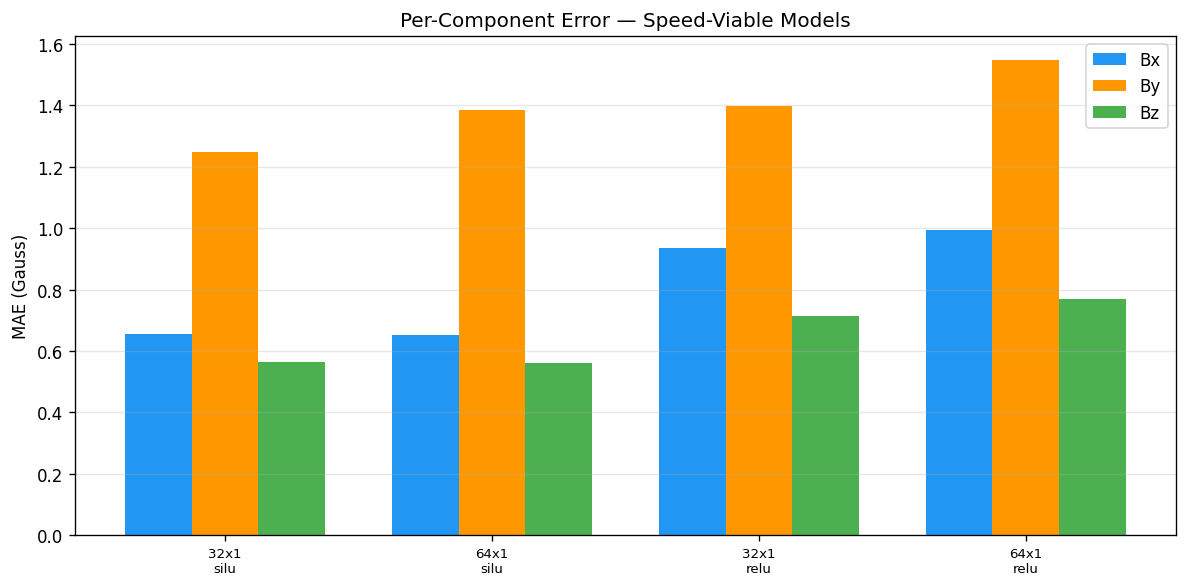

In [7]:
# Per-component error bars
if not viable[['bx_mae','by_mae','bz_mae']].isna().all().all():
    fig, ax = plt.subplots(figsize=(10, 5))
    x_pos = np.arange(len(viable))
    w = 0.25
    ax.bar(x_pos - w, viable['bx_mae'], w, label='Bx', color='#2196F3')
    ax.bar(x_pos,     viable['by_mae'], w, label='By', color='#FF9800')
    ax.bar(x_pos + w, viable['bz_mae'], w, label='Bz', color='#4CAF50')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{r['width']}x{r['depth']}\n{r['activation']}"
                        for _, r in viable.iterrows()], fontsize=8)
    ax.set_ylabel('MAE (Gauss)')
    ax.set_title('Per-Component Error — Speed-Viable Models')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('per_component_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Per-component data not available.')

---
## Part II: Trajectory Comparison

We implement the LHCb track extrapolation equations of motion in Python and propagate test tracks from z=200 mm to z=9500 mm using:
1. **Trilinear field map** (the standard LHCb approach)
2. **NN field** (the best speed-viable and best overall models)

This replicates what the C++ Gaudi extrapolators do, using the exact same Lorentz force equation from `TrackRungeKuttaExtrapolator::evaluateDerivatives()`:
```
dState/dz = (tx, ty, qop*Ax, qop*Ay)
where norm = sqrt(1 + tx^2 + ty^2)
      Ax = norm * (ty*(tx*Bx + Bz) - (1+tx^2)*By)
      Ay = norm * (-tx*(ty*By + Bz) + (1+ty^2)*Bx)
```

**Stepping methods** implemented:
- **Euler** (1st order) — simple forward step
- **RK4** (4th order) — classic Runge-Kutta
- **CashKarp** (adaptive 4th/5th order) — matches `TrackRungeKuttaExtrapolator`
- **Parabolic** (2nd order midpoint) — matches `TrackParabolicExtrapolator`

In [8]:
# Load field map and NN models
import torch
from trilinear import TrilinearGrid
from train_field_nn import FieldMLP

# Load trilinear field map
FIELD_MAP_PATH = PROJECT / 'data' / 'twodip.rtf'
if not FIELD_MAP_PATH.exists():
    FIELD_MAP_PATH = PROJECT.parent / 'twodip.rtf'
if not FIELD_MAP_PATH.exists():
    # Search for it
    import glob
    candidates = glob.glob(str(WORKSPACE / '**' / 'twodip.rtf'), recursive=True)
    if candidates:
        FIELD_MAP_PATH = Path(candidates[0])
    else:
        raise FileNotFoundError('Cannot find twodip.rtf')

print(f'Loading field map: {FIELD_MAP_PATH}')
t0 = time.time()
grid = TrilinearGrid.from_file(str(FIELD_MAP_PATH))
print(f'  Grid: {grid.nx}x{grid.ny}x{grid.nz} = {grid.nx*grid.ny*grid.nz:,} points')
print(f'  Loaded in {time.time()-t0:.1f}s')

# Load NN models for comparison
def load_nn_model(model_name):
    """Load a trained NN model and its normalization."""
    model_dir = RESULTS / model_name
    with open(model_dir / 'model_config.json') as f:
        mcfg = json.load(f)
    with open(model_dir / 'normalization.json') as f:
        norm = json.load(f)

    model = FieldMLP(mcfg['hidden_dims'], mcfg['activation'])
    model.load_state_dict(torch.load(model_dir / 'model.pt', map_location='cpu', weights_only=True))
    model.eval()

    # Pre-compute normalization tensors
    in_mean  = torch.tensor(norm['input_mean'],  dtype=torch.float32)
    in_std   = torch.tensor(norm['input_std'],   dtype=torch.float32)
    out_mean = torch.tensor(norm['output_mean'], dtype=torch.float32)
    out_std  = torch.tensor(norm['output_std'],  dtype=torch.float32)

    @torch.no_grad()
    def nn_field(x, y, z):
        """Query NN field at single point. Returns (Bx,By,Bz) in Gauss."""
        inp = torch.tensor([[x, y, z]], dtype=torch.float32)
        inp_norm = (inp - in_mean) / in_std
        out_norm = model(inp_norm)
        out = out_norm * out_std + out_mean
        return out[0].numpy()  # (3,) array in Gauss

    return nn_field, mcfg

# Load best speed-viable and best overall
nn_viable, mcfg_viable = load_nn_model(best_viable['name'])
nn_best, mcfg_best = load_nn_model(best_overall['name'])

print(f'\nLoaded NN models:')
print(f'  Best viable: {best_viable["name"]} (MAE={best_viable["mae_gauss"]:.3f} G)')
print(f'  Best overall: {best_overall["name"]} (MAE={best_overall["mae_gauss"]:.3f} G)')

Loading field map: /data/bfys/gscriven/TrackExtrapolation/experiments/field_maps/twodip.rtf
  Grid: 81x81x146 = 957,906 points
  Loaded in 11.2s

Loaded NN models:
  Best viable: field_nn_silu_1L_32H (MAE=0.822 G)
  Best overall: field_nn_silu_3L_256H (MAE=0.499 G)


In [9]:
# Field lookup wrappers and sanity check

def trilinear_field(x, y, z):
    """Query trilinear field at single point. Returns (Bx,By,Bz) in Gauss."""
    return grid.query(np.array([[x, y, z]]))[0]

# Quick sanity check: compare trilinear and NN at a few points
test_points = [
    (0, 0, 5000),       # center of magnet
    (1000, 500, 5000),  # off-center in magnet
    (0, 0, 2500),       # upstream edge
    (0, 0, 9500),       # downstream, low field
    (2000, 2000, 5000), # far off-axis
]

print('Field comparison at test points (Gauss):')
print(f'{"x,y,z":>25}  {"Trilinear B":>35}  {"NN viable B":>35}  {"Error":>12}')
print('-' * 120)
for pt in test_points:
    b_tri = trilinear_field(*pt)
    b_nn  = nn_viable(*pt)
    err = np.abs(b_tri - b_nn)
    print(f'{str(pt):>25}  [{b_tri[0]:9.2f}, {b_tri[1]:9.2f}, {b_tri[2]:9.2f}]'
          f'  [{b_nn[0]:9.2f}, {b_nn[1]:9.2f}, {b_nn[2]:9.2f}]'
          f'  {np.mean(err):.3f}')

Field comparison at test points (Gauss):
                    x,y,z                          Trilinear B                          NN viable B         Error
------------------------------------------------------------------------------------------------------------------------
             (0, 0, 5000)  [     0.00,     -1.03,      0.00]  [    -0.11,     -1.38,      0.09]  0.181
        (1000, 500, 5000)  [     0.16,     -0.92,      0.00]  [     0.26,     -1.17,     -0.02]  0.123
             (0, 0, 2500)  [     0.00,     -0.36,      0.00]  [    -0.05,     -1.60,      0.04]  0.440
             (0, 0, 9500)  [     0.00,     -0.05,      0.00]  [    -0.04,     -1.03,      0.06]  0.359
       (2000, 2000, 5000)  [     1.04,     -0.48,      0.00]  [     0.99,     -0.44,     -0.13]  0.072


In [10]:
# Equation of Motion: Lorentz force in track parametrisation
#
# Matches TrackRungeKuttaExtrapolator::evaluateDerivatives() exactly.
# State: (x, y, tx, ty, qop) as functions of z
#
# In the C++ code the field values from fieldVectorLinearInterpolation
# are in Gaudi units (Tesla * c_light = MeV/(mm*e)).
# Our twodip.rtf field is in Gauss. We convert:
#   B_gaudi = B_gauss * 1e-4 * c_light

C_LIGHT = 299.792458  # mm/ns  (speed of light in Gaudi units)
GAUSS_TO_GAUDI = 1e-4 * C_LIGHT  # Gauss -> MeV/(mm*e)

def derivatives(state, Bx, By, Bz):
    """Compute dState/dz from the Lorentz force.

    state: (x, y, tx, ty, qop)  -- x,y in mm, qop in 1/MeV
    Bx, By, Bz: field in Gaudi units (MeV/(mm*e))
    Returns: (dx/dz, dy/dz, dtx/dz, dty/dz, 0)
    """
    x, y, tx, ty, qop = state
    tx2, ty2 = tx*tx, ty*ty
    norm = np.sqrt(1 + tx2 + ty2)

    Ax = norm * (ty * (tx * Bx + Bz) - (1 + tx2) * By)
    Ay = norm * (-tx * (ty * By + Bz) + (1 + ty2) * Bx)

    return np.array([tx, ty, qop * Ax, qop * Ay, 0.0])


def field_at(x, y, z, field_func):
    """Get field in Gaudi units at position (x,y,z) in mm."""
    B_gauss = field_func(x, y, z)  # returns Gauss
    return B_gauss * GAUSS_TO_GAUDI  # convert to MeV/(mm*e)


print(f'c_light = {C_LIGHT} mm/ns')
print(f'GAUSS_TO_GAUDI = {GAUSS_TO_GAUDI:.6f}')
print(f'1 Tesla = {1e4 * GAUSS_TO_GAUDI:.2f} Gaudi units')

c_light = 299.792458 mm/ns
GAUSS_TO_GAUDI = 0.029979
1 Tesla = 299.79 Gaudi units


In [11]:
# Extrapolator implementations

def extrapolate_euler(state, z_start, z_end, field_func, step=100.0):
    """Euler (1st order) extrapolation."""
    z = z_start
    s = state.copy()
    trajectory = [(z, s.copy())]

    direction = 1 if z_end > z_start else -1
    while direction * (z_end - z) > 0.01:
        dz = min(step, abs(z_end - z)) * direction
        B = field_at(s[0], s[1], z, field_func)
        ds = derivatives(s, B[0], B[1], B[2])
        s = s + dz * ds
        z += dz
        trajectory.append((z, s.copy()))

    return s, trajectory


def extrapolate_rk4(state, z_start, z_end, field_func, step=100.0):
    """Classic RK4 (4th order) extrapolation."""
    z = z_start
    s = state.copy()
    trajectory = [(z, s.copy())]

    direction = 1 if z_end > z_start else -1
    while direction * (z_end - z) > 0.01:
        dz = min(step, abs(z_end - z)) * direction

        B1 = field_at(s[0], s[1], z, field_func)
        k1 = derivatives(s, B1[0], B1[1], B1[2])

        s2 = s + 0.5 * dz * k1
        B2 = field_at(s2[0], s2[1], z + 0.5*dz, field_func)
        k2 = derivatives(s2, B2[0], B2[1], B2[2])

        s3 = s + 0.5 * dz * k2
        B3 = field_at(s3[0], s3[1], z + 0.5*dz, field_func)
        k3 = derivatives(s3, B3[0], B3[1], B3[2])

        s4 = s + dz * k3
        B4 = field_at(s4[0], s4[1], z + dz, field_func)
        k4 = derivatives(s4, B4[0], B4[1], B4[2])

        s = s + (dz / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        z += dz
        trajectory.append((z, s.copy()))

    return s, trajectory


def extrapolate_cashkarp(state, z_start, z_end, field_func,
                         initial_step=500.0, min_step=10.0, tol_x=0.5):
    """Cash-Karp adaptive RK4/5 extrapolation.

    Matches TrackRungeKuttaExtrapolator with StepMethod=CashKarp.
    Uses the Cash-Karp Butcher tableau for 4th/5th order embedded RK.
    """
    # Cash-Karp coefficients
    a = [
        [1/5],
        [3/40, 9/40],
        [3/10, -9/10, 6/5],
        [-11/54, 5/2, -70/27, 35/27],
        [1631/55296, 175/512, 575/13824, 44275/110592, 253/4096],
    ]
    b5 = [37/378, 0, 250/621, 125/594, 0, 512/1771]  # 5th order
    b4 = [2825/27648, 0, 18575/48384, 13525/55296, 277/14336, 1/4]  # 4th order

    z = z_start
    s = state.copy()
    trajectory = [(z, s.copy())]

    direction = 1 if z_end > z_start else -1
    total_step = abs(z_end - z_start)
    step = min(initial_step, total_step)

    max_iter = 10000
    iterations = 0
    while direction * (z_end - z) > 0.01 and iterations < max_iter:
        iterations += 1
        step = min(step, abs(z_end - z))
        dz = step * direction

        # Evaluate 6 stages
        k = [None] * 6

        # Stage 0
        B = field_at(s[0], s[1], z, field_func)
        k[0] = derivatives(s, B[0], B[1], B[2])

        # Stages 1-5
        c = [0, 1/5, 3/10, 3/5, 1, 7/8]
        for m in range(1, 6):
            sm = s.copy()
            for j in range(m):
                sm = sm + dz * a[m-1][j] * k[j]
            B = field_at(sm[0], sm[1], z + c[m]*dz, field_func)
            k[m] = derivatives(sm, B[0], B[1], B[2])

        # 5th order solution
        s_new = s.copy()
        for m in range(6):
            s_new = s_new + dz * b5[m] * k[m]

        # Error estimate (difference between 4th and 5th order)
        err = np.zeros(5)
        for m in range(6):
            err += dz * (b5[m] - b4[m]) * k[m]

        # Acceptance criterion
        tol_tx = tol_x / total_step
        err_x = max(abs(err[0]), abs(err[1])) / tol_x if tol_x > 0 else 0
        err_tx = max(abs(err[2]), abs(err[3])) / tol_tx if tol_tx > 0 else 0
        err_norm = max(err_x, err_tx)

        if err_norm <= 1.0 or step <= min_step:
            s = s_new
            z += dz
            trajectory.append((z, s.copy()))

        # Adapt step size
        if err_norm > 0:
            step = step * min(2.0, max(0.2, 0.9 * err_norm**(-0.2)))
        step = max(step, min_step)

    return s, trajectory


def extrapolate_parabolic(state, z_start, z_end, field_func, step=100.0):
    """Parabolic extrapolation (2nd order midpoint).

    Matches TrackParabolicExtrapolator.
    Uses field at start to predict midpoint, then field at midpoint for full step.
    """
    z = z_start
    s = state.copy()
    trajectory = [(z, s.copy())]

    direction = 1 if z_end > z_start else -1
    while direction * (z_end - z) > 0.01:
        dz = min(step, abs(z_end - z)) * direction

        # Field at start
        B1 = field_at(s[0], s[1], z, field_func)
        k1 = derivatives(s, B1[0], B1[1], B1[2])

        # Predict midpoint using Euler
        s_mid = s + 0.5 * dz * k1
        B_mid = field_at(s_mid[0], s_mid[1], z + 0.5*dz, field_func)
        k_mid = derivatives(s_mid, B_mid[0], B_mid[1], B_mid[2])

        # Update using midpoint derivative (2nd order)
        s = s + dz * k_mid
        z += dz
        trajectory.append((z, s.copy()))

    return s, trajectory


print('Extrapolator functions defined: euler, rk4, cashkarp, parabolic')

Extrapolator functions defined: euler, rk4, cashkarp, parabolic


In [12]:
# Define test tracks
# State: (x, y, tx, ty, qop) -- x,y in mm, tx=dx/dz, ty=dy/dz, qop in 1/MeV

Z_START = 200.0    # mm -- before magnet
Z_END   = 9500.0   # mm -- after magnet

test_tracks = [
    # (label, initial_state)
    ('5 GeV, central',       np.array([0.0, 0.0, 0.0, 0.0, 1.0/5000])),
    ('5 GeV, negative',      np.array([0.0, 0.0, 0.0, 0.0, -1.0/5000])),
    ('2 GeV, central',       np.array([0.0, 0.0, 0.0, 0.0, 1.0/2000])),
    ('10 GeV, central',      np.array([0.0, 0.0, 0.0, 0.0, 1.0/10000])),
    ('50 GeV, central',      np.array([0.0, 0.0, 0.0, 0.0, 1.0/50000])),
    ('5 GeV, angled',        np.array([100.0, 50.0, 0.05, 0.02, 1.0/5000])),
    ('5 GeV, wide angle',    np.array([200.0, 100.0, 0.15, 0.08, 1.0/5000])),
    ('5 GeV, off-center',    np.array([500.0, 300.0, 0.02, 0.01, 1.0/5000])),
    ('3 GeV, tilted',        np.array([0.0, 0.0, 0.10, 0.05, 1.0/3000])),
    ('1 GeV, central',       np.array([0.0, 0.0, 0.0, 0.0, 1.0/1000])),
]

extrapolators = [
    ('Euler',     extrapolate_euler,    dict(step=100.0)),
    ('RK4',       extrapolate_rk4,      dict(step=100.0)),
    ('CashKarp',  extrapolate_cashkarp, dict(initial_step=500.0)),
    ('Parabolic', extrapolate_parabolic, dict(step=100.0)),
]

print(f'Test setup: {len(test_tracks)} tracks x {len(extrapolators)} extrapolators x 3 field sources')
print(f'Propagation: z = {Z_START} -> {Z_END} mm')

Test setup: 10 tracks x 4 extrapolators x 3 field sources
Propagation: z = 200.0 -> 9500.0 mm


In [13]:
# Run all trajectories
results = []

# Field sources to compare
field_sources = [
    ('Trilinear', trilinear_field),
    ('NN (viable)', nn_viable),
    ('NN (best)', nn_best),
]

print('Running trajectory comparisons...')
t0 = time.time()

for track_label, initial_state in test_tracks:
    for ext_name, ext_func, ext_kwargs in extrapolators:
        for field_label, field_func in field_sources:
            s_final, traj = ext_func(initial_state, Z_START, Z_END,
                                     field_func, **ext_kwargs)
            results.append({
                'track': track_label,
                'extrapolator': ext_name,
                'field': field_label,
                'x_final': s_final[0],
                'y_final': s_final[1],
                'tx_final': s_final[2],
                'ty_final': s_final[3],
                'n_steps': len(traj) - 1,
                'trajectory': traj,
            })
    print(f'  {track_label}: done')

dt = time.time() - t0
print(f'\nAll trajectories computed in {dt:.1f}s ({len(results)} total)')

Running trajectory comparisons...


  5 GeV, central: done
  5 GeV, negative: done
  2 GeV, central: done
  10 GeV, central: done
  50 GeV, central: done
  5 GeV, angled: done
  5 GeV, wide angle: done
  5 GeV, off-center: done
  3 GeV, tilted: done
  1 GeV, central: done

All trajectories computed in 4.3s (120 total)


In [14]:
# Compute differences: NN vs Trilinear for each (track, extrapolator)
rdf = pd.DataFrame([{k: v for k, v in r.items() if k != 'trajectory'} for r in results])

# Keep trajectories separately to avoid DataFrame overhead
traj_lookup = {}
for r in results:
    key = (r['track'], r['extrapolator'], r['field'])
    traj_lookup[key] = r['trajectory']

# Pivot to compare field sources side by side
diff_rows = []
for (track, ext), grp in rdf.groupby(['track', 'extrapolator']):
    tri_row = grp[grp['field'] == 'Trilinear'].iloc[0]
    for field_label in ['NN (viable)', 'NN (best)']:
        nn_row = grp[grp['field'] == field_label].iloc[0]
        diff_rows.append({
            'track': track,
            'extrapolator': ext,
            'nn_model': field_label,
            'dx_mm': abs(nn_row['x_final'] - tri_row['x_final']),
            'dy_mm': abs(nn_row['y_final'] - tri_row['y_final']),
            'dtx': abs(nn_row['tx_final'] - tri_row['tx_final']),
            'dty': abs(nn_row['ty_final'] - tri_row['ty_final']),
            'dr_mm': np.sqrt((nn_row['x_final'] - tri_row['x_final'])**2 +
                             (nn_row['y_final'] - tri_row['y_final'])**2),
        })

diffs = pd.DataFrame(diff_rows)

print('=== Trajectory differences: NN vs Trilinear ===')
print(f'(position error at z={Z_END} mm after propagation from z={Z_START} mm)\n')

# Summary by extrapolator and NN model
summary = diffs.groupby(['extrapolator', 'nn_model']).agg(
    mean_dr_mm=('dr_mm', 'mean'),
    max_dr_mm=('dr_mm', 'max'),
    mean_dtx=('dtx', 'mean'),
    max_dtx=('dtx', 'max'),
).reset_index()

print(summary.to_string(index=False))

=== Trajectory differences: NN vs Trilinear ===
(position error at z=9500.0 mm after propagation from z=200.0 mm)

extrapolator    nn_model  mean_dr_mm   max_dr_mm  mean_dtx  max_dtx
    CashKarp   NN (best)  236.748946  847.424635  0.051351 0.184650
    CashKarp NN (viable)  421.055286 1503.482047  0.086451 0.325138
       Euler   NN (best)  231.528282  829.774826  0.051315 0.184675
       Euler NN (viable)  420.708963 1499.016071  0.086739 0.326087
   Parabolic   NN (best)  236.461591  847.796354  0.051321 0.184675
   Parabolic NN (viable)  421.477516 1503.724710  0.086493 0.325112
         RK4   NN (best)  236.456778  847.782666  0.051320 0.184672
         RK4 NN (viable)  421.475231 1503.723218  0.086493 0.325108


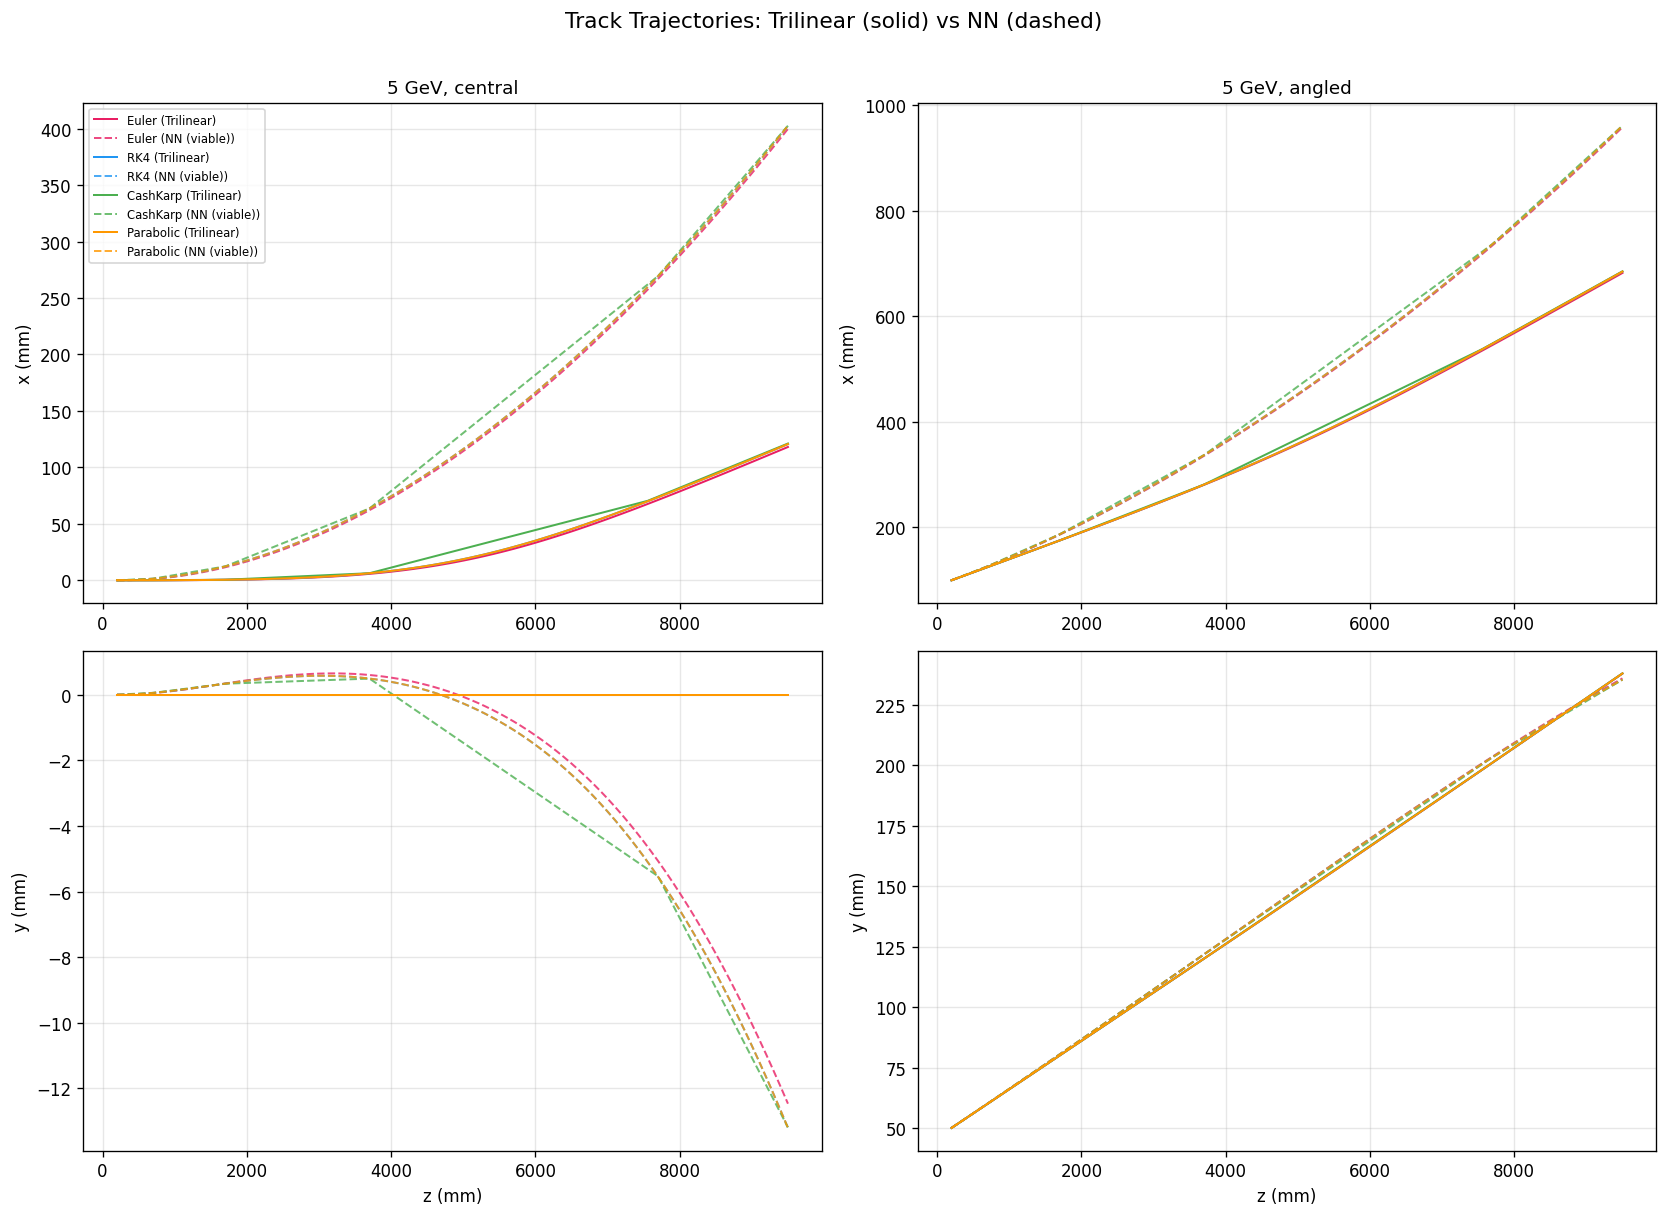

In [15]:
# Plot 1: Trajectory comparison for representative tracks
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_tracks = ['5 GeV, central', '5 GeV, angled']
ext_colors = {'Euler': '#E91E63', 'RK4': '#2196F3', 'CashKarp': '#4CAF50', 'Parabolic': '#FF9800'}

for col, track_label in enumerate(plot_tracks):
    for ext_name, _, _ in extrapolators:
        color = ext_colors[ext_name]
        for field_label, ls, alpha in [('Trilinear', '-', 1.0),
                                        ('NN (viable)', '--', 0.8)]:
            key = (track_label, ext_name, field_label)
            if key not in traj_lookup:
                continue
            traj = traj_lookup[key]
            zz = [t[0] for t in traj]
            xx = [t[1][0] for t in traj]
            yy = [t[1][1] for t in traj]

            label = f'{ext_name} ({field_label})' if col == 0 else None
            axes[0, col].plot(zz, xx, ls=ls, alpha=alpha, color=color,
                             label=label, linewidth=1.2)
            axes[1, col].plot(zz, yy, ls=ls, alpha=alpha, color=color,
                             label=label, linewidth=1.2)

    axes[0, col].set_title(f'{track_label}', fontsize=11)
    axes[0, col].set_ylabel('x (mm)')
    axes[1, col].set_ylabel('y (mm)')
    axes[1, col].set_xlabel('z (mm)')

    for ax in [axes[0, col], axes[1, col]]:
        ax.grid(True, alpha=0.3)

axes[0, 0].legend(fontsize=7, loc='best')
fig.suptitle('Track Trajectories: Trilinear (solid) vs NN (dashed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

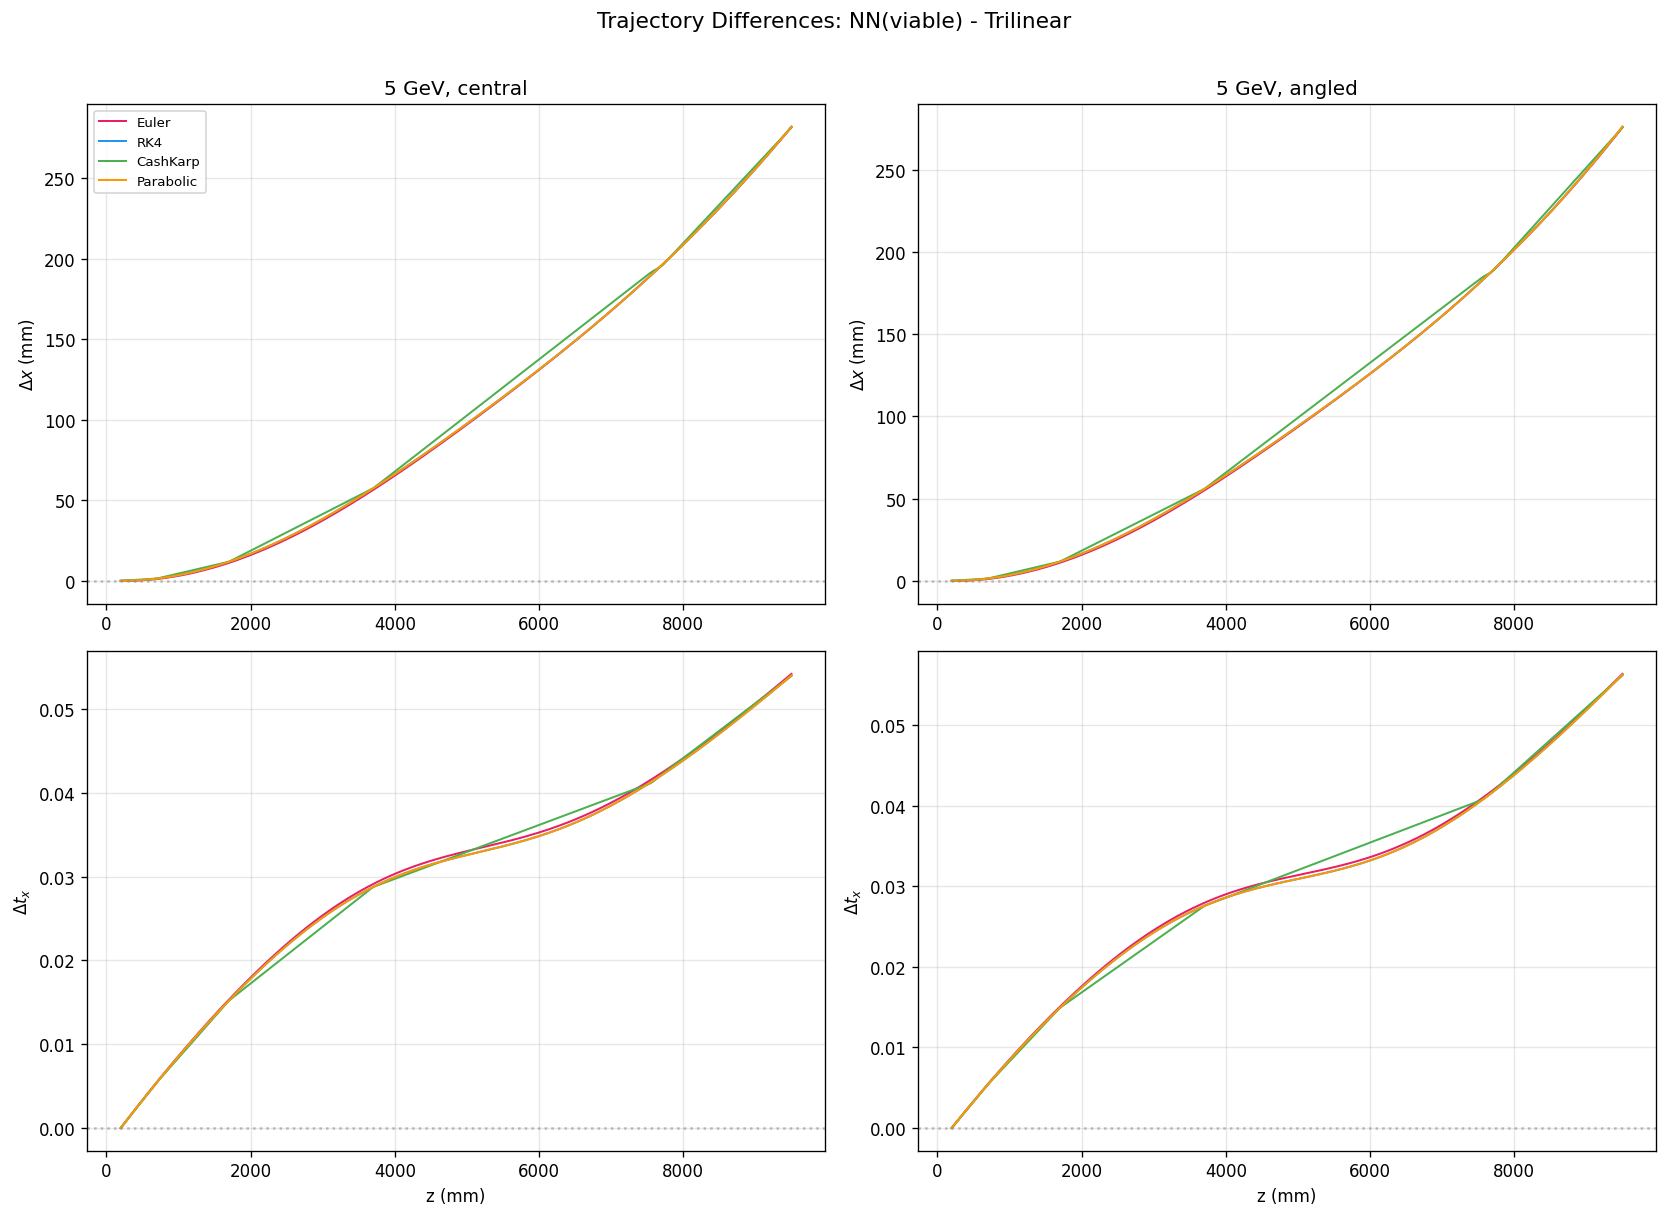

In [16]:
# Plot 2: Trajectory differences (NN - Trilinear) along z
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, track_label in enumerate(plot_tracks):
    for ext_name, _, _ in extrapolators:
        color = ext_colors[ext_name]
        key_tri = (track_label, ext_name, 'Trilinear')
        key_nn = (track_label, ext_name, 'NN (viable)')

        if key_tri not in traj_lookup or key_nn not in traj_lookup:
            continue

        traj_tri = traj_lookup[key_tri]
        traj_nn = traj_lookup[key_nn]

        # Interpolate to common z grid for comparison
        z_tri = np.array([t[0] for t in traj_tri])
        x_tri = np.array([t[1][0] for t in traj_tri])
        tx_tri = np.array([t[1][2] for t in traj_tri])

        z_nn = np.array([t[0] for t in traj_nn])
        x_nn = np.array([t[1][0] for t in traj_nn])
        tx_nn = np.array([t[1][2] for t in traj_nn])

        z_common = np.linspace(Z_START, Z_END, 200)
        dx = np.interp(z_common, z_nn, x_nn) - np.interp(z_common, z_tri, x_tri)
        dtx = np.interp(z_common, z_nn, tx_nn) - np.interp(z_common, z_tri, tx_tri)

        label = ext_name if col == 0 else None
        axes[0, col].plot(z_common, dx, label=label, linewidth=1.2, color=color)
        axes[1, col].plot(z_common, dtx, label=label, linewidth=1.2, color=color)

    axes[0, col].set_title(f'{track_label}')
    axes[0, col].set_ylabel('$\\Delta x$ (mm)')
    axes[1, col].set_ylabel('$\\Delta t_x$')
    axes[1, col].set_xlabel('z (mm)')

    for ax in [axes[0, col], axes[1, col]]:
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='gray', ls=':', alpha=0.5)

axes[0, 0].legend(fontsize=8)
fig.suptitle('Trajectory Differences: NN(viable) - Trilinear', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('trajectory_differences.png', dpi=150, bbox_inches='tight')
plt.show()

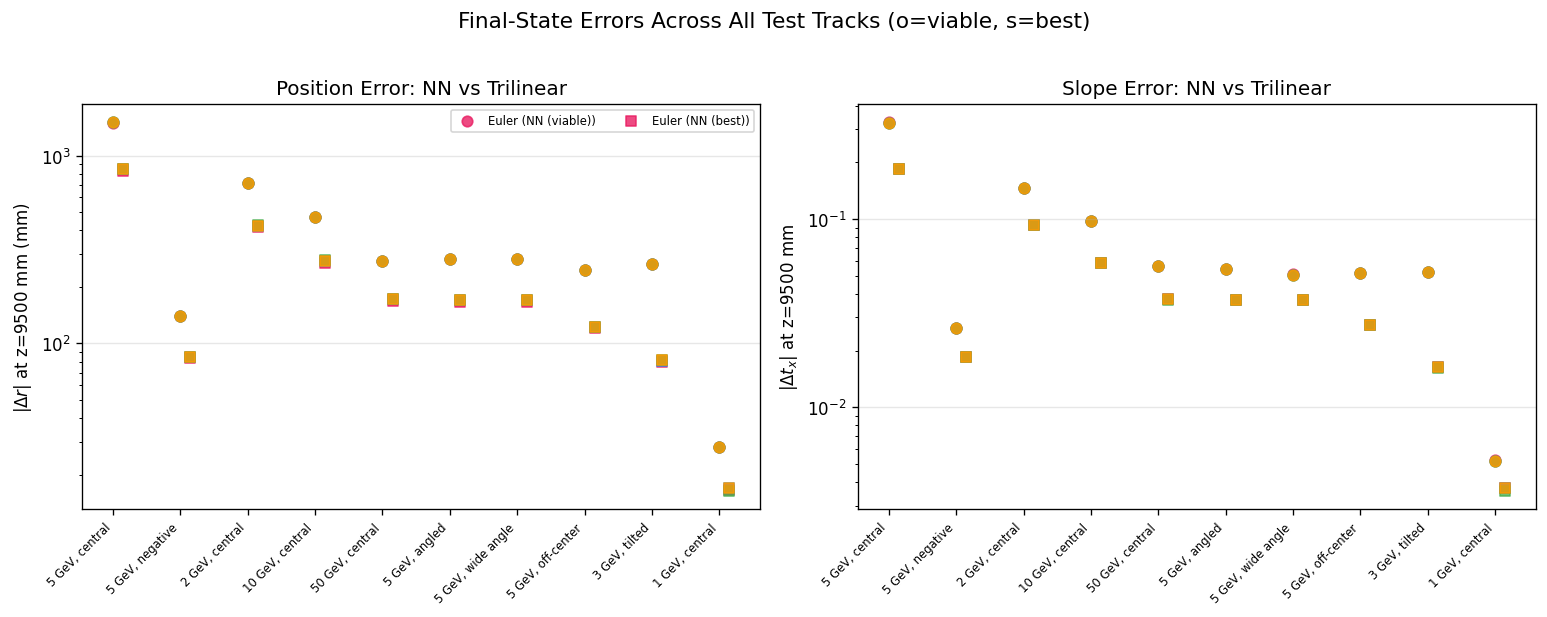

In [17]:
# Plot 3: Final-state error summary across all tracks
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nn_label, marker, color_off in [('NN (viable)', 'o', 0), ('NN (best)', 's', 0.15)]:
    sub = diffs[diffs['nn_model'] == nn_label]
    for ext_idx, ext_name in enumerate(['Euler', 'RK4', 'CashKarp', 'Parabolic']):
        ext_sub = sub[sub['extrapolator'] == ext_name]
        x_track_indices = np.arange(len(ext_sub)) + color_off
        axes[0].scatter(x_track_indices, ext_sub['dr_mm'],
                       marker=marker, s=40,
                       label=f'{ext_name} ({nn_label})' if ext_idx == 0 else None,
                       color=ext_colors[ext_name], alpha=0.8)
        axes[1].scatter(x_track_indices, ext_sub['dtx'],
                       marker=marker, s=40,
                       color=ext_colors[ext_name], alpha=0.8)

for ax in axes:
    track_labels = [t[0] for t in test_tracks]
    ax.set_xticks(range(len(track_labels)))
    ax.set_xticklabels(track_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')

axes[0].set_ylabel('$|\\Delta r|$ at z=9500 mm (mm)')
axes[0].set_title('Position Error: NN vs Trilinear')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_ylabel('$|\\Delta t_x|$ at z=9500 mm')
axes[1].set_title('Slope Error: NN vs Trilinear')

fig.suptitle('Final-State Errors Across All Test Tracks (o=viable, s=best)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('final_state_errors.png', dpi=150, bbox_inches='tight')
plt.show()

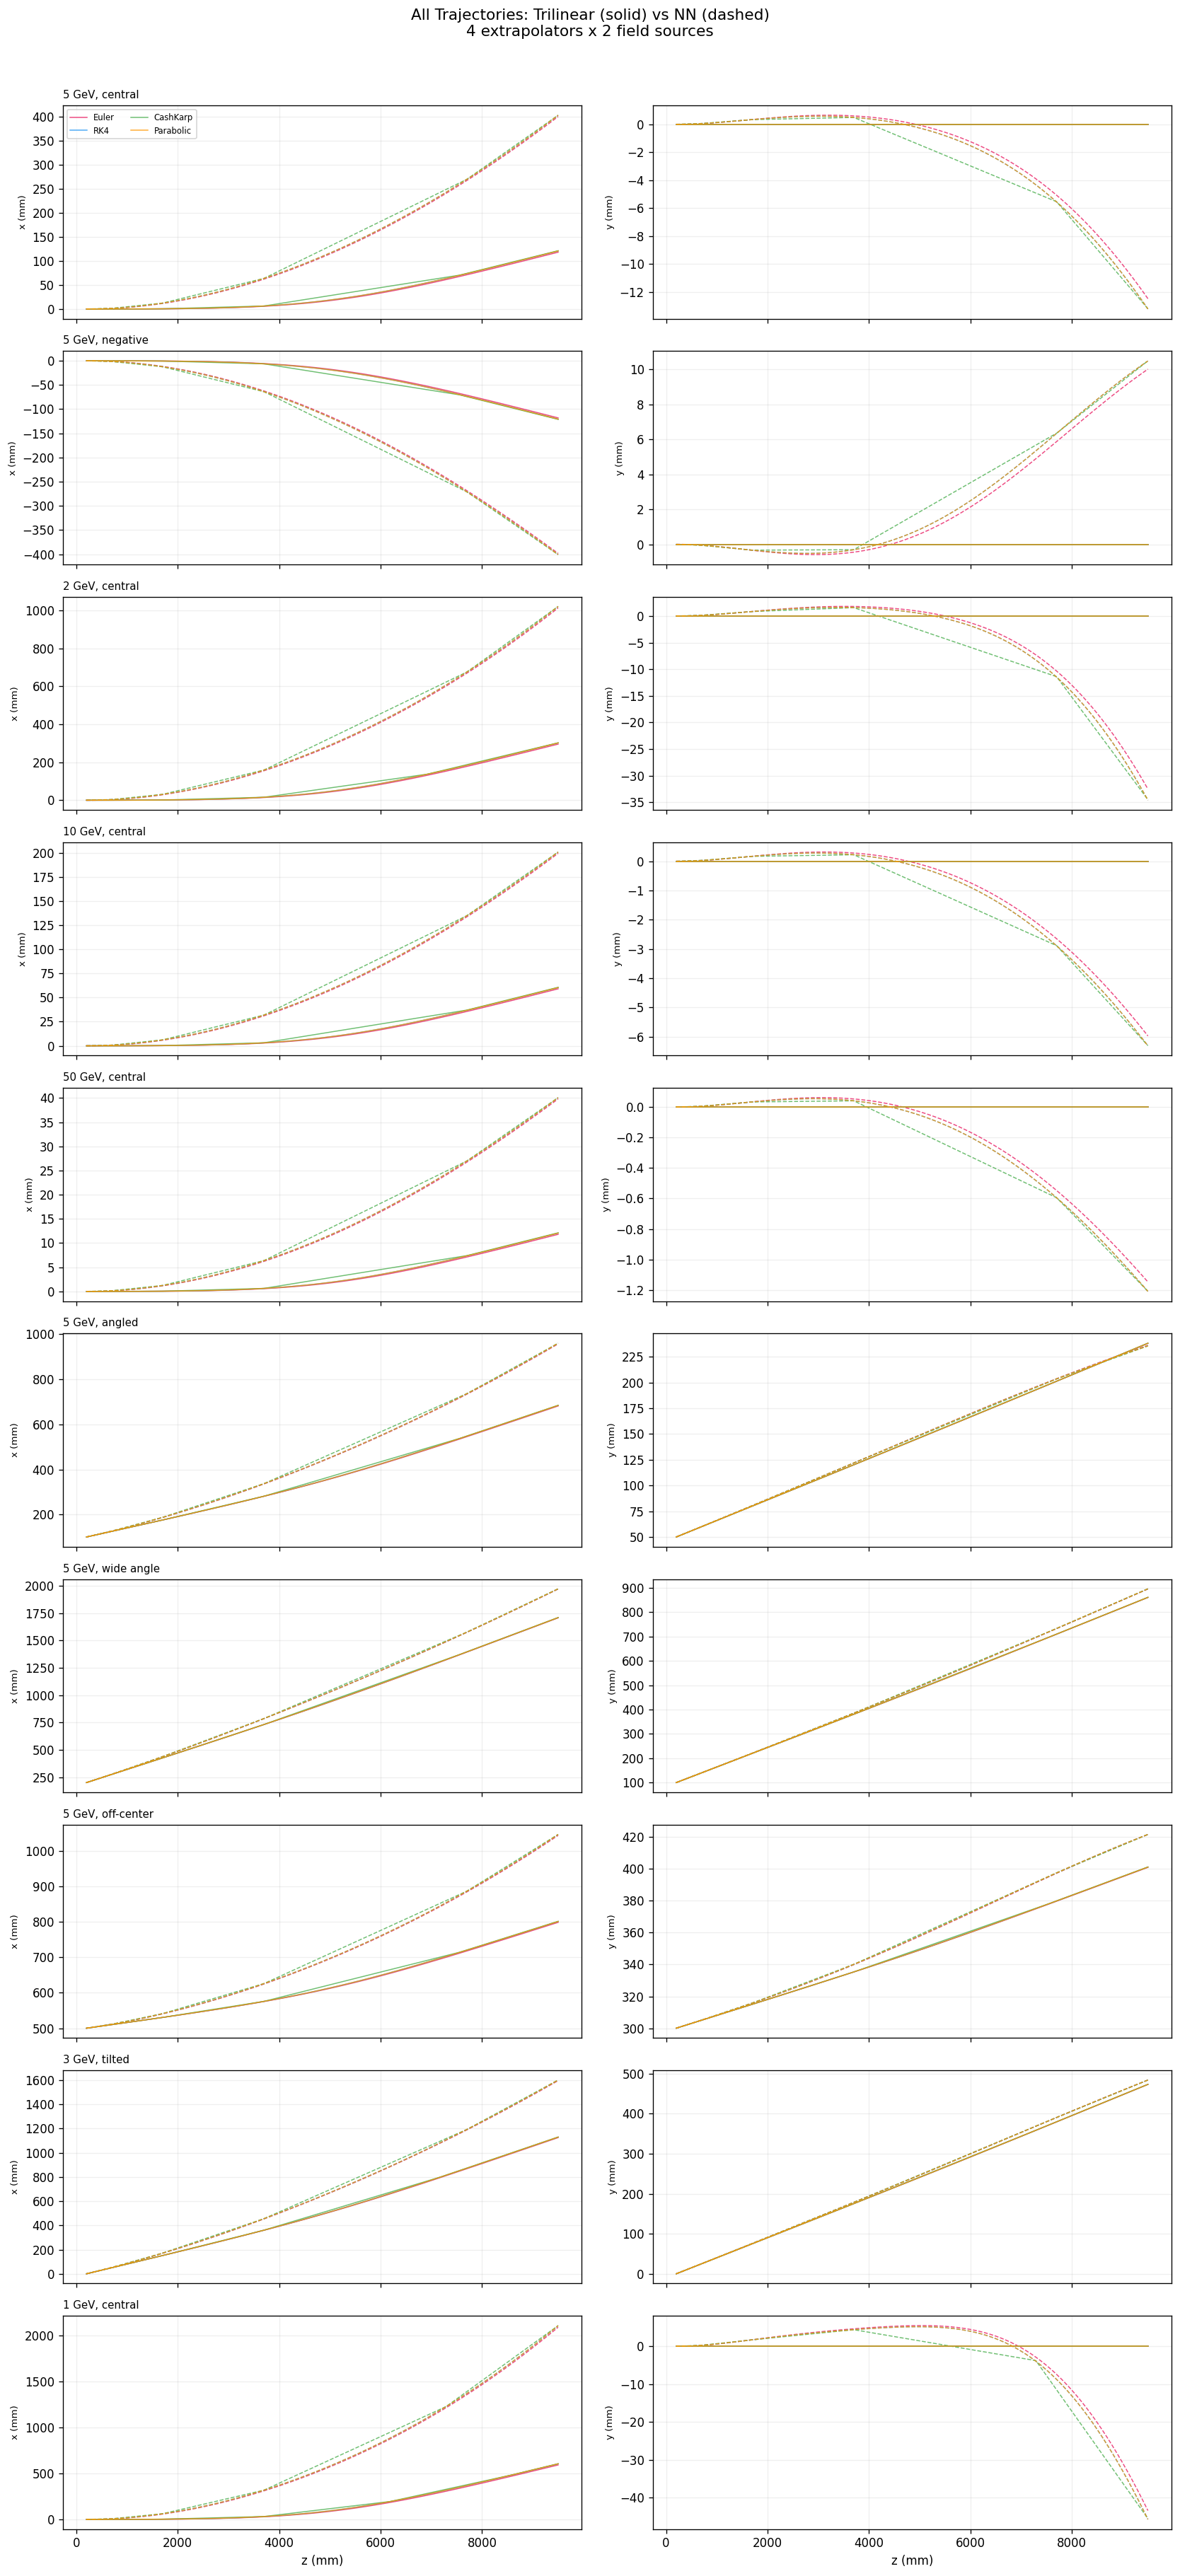

In [18]:
# Plot 4: All trajectories grid
n_tracks = len(test_tracks)
fig, axes = plt.subplots(n_tracks, 2, figsize=(14, 3 * n_tracks), sharex=True)

for row_idx, (track_label, _) in enumerate(test_tracks):
    for ext_name, _, _ in extrapolators:
        color = ext_colors[ext_name]
        for field_label, ls in [('Trilinear', '-'), ('NN (viable)', '--')]:
            key = (track_label, ext_name, field_label)
            if key not in traj_lookup:
                continue
            traj = traj_lookup[key]
            zz = [t[0] for t in traj]
            xx = [t[1][0] for t in traj]
            yy = [t[1][1] for t in traj]

            label = f'{ext_name}' if field_label == 'Trilinear' and row_idx == 0 else None
            axes[row_idx, 0].plot(zz, xx, ls=ls, linewidth=0.9, alpha=0.8,
                                 color=color, label=label)
            axes[row_idx, 1].plot(zz, yy, ls=ls, linewidth=0.9, alpha=0.8,
                                 color=color)

    axes[row_idx, 0].set_ylabel('x (mm)', fontsize=8)
    axes[row_idx, 1].set_ylabel('y (mm)', fontsize=8)
    axes[row_idx, 0].set_title(f'{track_label}', fontsize=9, loc='left')
    axes[row_idx, 0].grid(True, alpha=0.2)
    axes[row_idx, 1].grid(True, alpha=0.2)

axes[-1, 0].set_xlabel('z (mm)')
axes[-1, 1].set_xlabel('z (mm)')
axes[0, 0].legend(fontsize=7, ncol=2)

fig.suptitle('All Trajectories: Trilinear (solid) vs NN (dashed)\n'
             f'{len(extrapolators)} extrapolators x 2 field sources',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('all_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Comprehensive summary statistics
print('\n' + '='*80)
print('COMPREHENSIVE TRAJECTORY COMPARISON SUMMARY')
print('='*80)
print(f'\nPropagation: z = {Z_START} -> {Z_END} mm')
print(f'Test tracks: {len(test_tracks)}')
print(f'Extrapolators: {[e[0] for e in extrapolators]}')
print(f'Field sources: {[f[0] for f in field_sources]}')

print(f'\nBest speed-viable NN: {best_viable["name"]}')
print(f'  Architecture: {best_viable["width"]}x{best_viable["depth"]} {best_viable["activation"]}')
print(f'  Field MAE: {best_viable["mae_gauss"]:.3f} Gauss')
print(f'  FLOPs: {best_viable["flops"]}, Weight memory: {best_viable["weight_kb"]:.1f} KB')

print(f'\nBest overall NN: {best_overall["name"]}')
print(f'  Architecture: {best_overall["width"]}x{best_overall["depth"]} {best_overall["activation"]}')
print(f'  Field MAE: {best_overall["mae_gauss"]:.3f} Gauss')
print(f'  FLOPs: {best_overall["flops"]}, Weight memory: {best_overall["weight_kb"]:.1f} KB')

# Per-extrapolator summary
print('\n--- Per-Extrapolator Error Summary (NN viable vs Trilinear) ---')
viable_diffs = diffs[diffs['nn_model'] == 'NN (viable)']
for ext in ['CashKarp', 'RK4', 'Parabolic', 'Euler']:
    sub = viable_diffs[viable_diffs['extrapolator'] == ext]
    print(f'\n  {ext}:')
    print(f'    Position error |dr|: mean={sub["dr_mm"].mean():.4f} mm, '
          f'max={sub["dr_mm"].max():.4f} mm')
    print(f'    Slope error  |dtx|:  mean={sub["dtx"].mean():.2e}, '
          f'max={sub["dtx"].max():.2e}')

print('\n--- Per-Extrapolator Error Summary (NN best vs Trilinear) ---')
best_diffs = diffs[diffs['nn_model'] == 'NN (best)']
for ext in ['CashKarp', 'RK4', 'Parabolic', 'Euler']:
    sub = best_diffs[best_diffs['extrapolator'] == ext]
    print(f'\n  {ext}:')
    print(f'    Position error |dr|: mean={sub["dr_mm"].mean():.4f} mm, '
          f'max={sub["dr_mm"].max():.4f} mm')
    print(f'    Slope error  |dtx|:  mean={sub["dtx"].mean():.2e}, '
          f'max={sub["dtx"].max():.2e}')


COMPREHENSIVE TRAJECTORY COMPARISON SUMMARY

Propagation: z = 200.0 -> 9500.0 mm
Test tracks: 10
Extrapolators: ['Euler', 'RK4', 'CashKarp', 'Parabolic']
Field sources: ['Trilinear', 'NN (viable)', 'NN (best)']

Best speed-viable NN: field_nn_silu_1L_32H
  Architecture: 32x1 silu
  Field MAE: 0.822 Gauss
  FLOPs: 512, Weight memory: 0.9 KB

Best overall NN: field_nn_silu_3L_256H
  Architecture: 256x3 silu
  Field MAE: 0.499 Gauss
  FLOPs: 268288, Weight memory: 521.0 KB

--- Per-Extrapolator Error Summary (NN viable vs Trilinear) ---

  CashKarp:
    Position error |dr|: mean=421.0553 mm, max=1503.4820 mm
    Slope error  |dtx|:  mean=8.65e-02, max=3.25e-01

  RK4:
    Position error |dr|: mean=421.4752 mm, max=1503.7232 mm
    Slope error  |dtx|:  mean=8.65e-02, max=3.25e-01

  Parabolic:
    Position error |dr|: mean=421.4775 mm, max=1503.7247 mm
    Slope error  |dtx|:  mean=8.65e-02, max=3.25e-01

  Euler:
    Position error |dr|: mean=420.7090 mm, max=1499.0161 mm
    Slope error

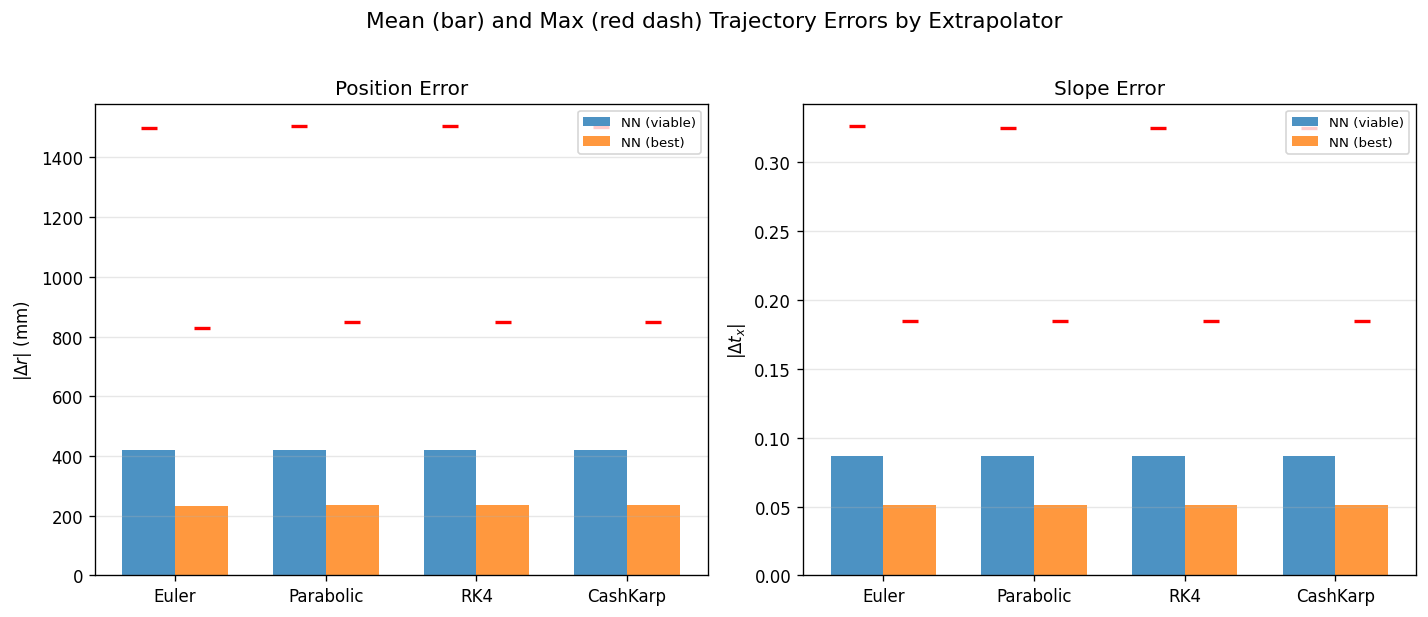

In [20]:
# Error bar chart per extrapolator
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ext_names = ['Euler', 'Parabolic', 'RK4', 'CashKarp']
x_pos = np.arange(len(ext_names))
w = 0.35

for ax_idx, (metric, ylabel, title) in enumerate([
    ('dr_mm', '$|\\Delta r|$ (mm)', 'Position Error'),
    ('dtx', '$|\\Delta t_x|$', 'Slope Error'),
]):
    for i, (nn_label, offset) in enumerate([('NN (viable)', -w/2), ('NN (best)', w/2)]):
        sub = diffs[diffs['nn_model'] == nn_label]
        means = [sub[sub['extrapolator'] == e][metric].mean() for e in ext_names]
        maxes = [sub[sub['extrapolator'] == e][metric].max() for e in ext_names]

        bars = axes[ax_idx].bar(x_pos + offset, means, w, label=nn_label,
                                alpha=0.8)
        axes[ax_idx].scatter(x_pos + offset, maxes, color='red', marker='_',
                             s=100, zorder=5, linewidths=2)

    axes[ax_idx].set_xticks(x_pos)
    axes[ax_idx].set_xticklabels(ext_names)
    axes[ax_idx].set_ylabel(ylabel)
    axes[ax_idx].set_title(title)
    axes[ax_idx].legend(fontsize=8)
    axes[ax_idx].grid(True, alpha=0.3, axis='y')

fig.suptitle('Mean (bar) and Max (red dash) Trajectory Errors by Extrapolator',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('error_by_extrapolator.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Table: detailed per-track results for CashKarp
print('\n=== Detailed CashKarp Results: NN (viable) vs Trilinear ===')
ck_viable = viable_diffs[viable_diffs['extrapolator'] == 'CashKarp'].copy()
ck_viable = ck_viable.sort_values('dr_mm', ascending=False)
print(ck_viable[['track', 'dx_mm', 'dy_mm', 'dtx', 'dty', 'dr_mm']].to_string(index=False))

print('\n=== Detailed CashKarp Results: NN (best overall) vs Trilinear ===')
ck_best = best_diffs[best_diffs['extrapolator'] == 'CashKarp'].copy()
ck_best = ck_best.sort_values('dr_mm', ascending=False)
print(ck_best[['track', 'dx_mm', 'dy_mm', 'dtx', 'dty', 'dr_mm']].to_string(index=False))


=== Detailed CashKarp Results: NN (viable) vs Trilinear ===
            track       dx_mm     dy_mm      dtx      dty       dr_mm
   1 GeV, central 1502.792388 45.533552 0.325138 0.027556 1503.482047
   2 GeV, central  718.024983 34.525875 0.146356 0.017295  718.854583
    3 GeV, tilted  471.089919 10.725431 0.097202 0.001404  471.211997
   5 GeV, central  281.430013 13.187772 0.053937 0.005287  281.738832
  5 GeV, negative  279.740932 10.496515 0.050427 0.001959  279.937789
    5 GeV, angled  275.669427  2.570761 0.056167 0.004012  275.681414
5 GeV, wide angle  262.592594 34.953515 0.052254 0.006808  264.908699
5 GeV, off-center  245.646815 20.456297 0.051515 0.000504  246.497095
  10 GeV, central  140.109148  6.308919 0.026334 0.002250  140.251117
  50 GeV, central   27.963175  1.208633 0.005183 0.000383   27.989283

=== Detailed CashKarp Results: NN (best overall) vs Trilinear ===
            track      dx_mm      dy_mm      dtx      dty      dr_mm
   1 GeV, central 839.534454 115.

### Relative Field Error: (NN − Trilinear) / Trilinear

Evaluate relative error of B-field predictions across the full grid volume.
Points where |B_component| < 1 Gauss are excluded to avoid division-by-near-zero artifacts.

In [22]:
# ── Relative B-field error: (NN − Trilinear) / Trilinear ──────────────────────
N_SAMPLE = 200_000

rng = np.random.default_rng(123)
pts = grid.random_off_grid_points(N_SAMPLE, rng=rng)
B_true = grid.query(pts)  # (N, 3) in Gauss

# Batch NN inference
def batch_nn_field(model_name):
    """Batch-evaluate an NN model at all sample points."""
    model_dir = RESULTS / model_name
    with open(model_dir / 'model_config.json') as f:
        mc = json.load(f)
    with open(model_dir / 'normalization.json') as f:
        norm = json.load(f)
    model = FieldMLP(mc['hidden_dims'], mc['activation'])
    model.load_state_dict(torch.load(model_dir / 'model.pt',
                                      map_location='cpu', weights_only=True))
    model.eval()
    in_mean  = torch.tensor(norm['input_mean'],  dtype=torch.float32)
    in_std   = torch.tensor(norm['input_std'],   dtype=torch.float32)
    out_mean = torch.tensor(norm['output_mean'], dtype=torch.float32)
    out_std  = torch.tensor(norm['output_std'],  dtype=torch.float32)
    with torch.no_grad():
        inp = torch.tensor(pts, dtype=torch.float32)
        out = model((inp - in_mean) / in_std) * out_std + out_mean
    return out.numpy()

B_viable = batch_nn_field(best_viable['name'])
B_best   = batch_nn_field(best_overall['name'])

# Field magnitude of the trilinear (truth)
B_mag_true = np.linalg.norm(B_true, axis=1)
print(f'Field magnitude statistics (Gauss) over {N_SAMPLE:,} random points:')
print(f'  min={B_mag_true.min():.2f}, median={np.median(B_mag_true):.2f}, '
      f'mean={B_mag_true.mean():.2f}, max={B_mag_true.max():.2f}')
for pct in [25, 50, 75, 90, 95, 99]:
    print(f'  p{pct:2d} = {np.percentile(B_mag_true, pct):.2f} G')

# Compute relative error per component at multiple |B| thresholds
comp_labels = ['Bx', 'By', 'Bz']
THRESHOLDS = [1, 10, 100, 500, 1000, 5000]

for nn_label, B_pred in [('NN viable (silu 32x1)', B_viable),
                          ('NN best (silu 256x3)',  B_best)]:
    print(f'\n{"="*80}')
    print(f'  Relative error (pred-true)/true : {nn_label}')
    print(f'{"="*80}')

    for threshold in THRESHOLDS:
        # Per-component relative error
        print(f'\n  --- |B_component| >= {threshold} Gauss ---')
        print(f'  {"Comp":>6}  {"N kept":>8}  {"mean":>10}  {"median":>10}'
              f'  {"std":>10}  {"p95(|.|)":>10}  {"max(|.|)":>10}')
        for ci, cl in enumerate(comp_labels):
            mask = np.abs(B_true[:, ci]) >= threshold
            if mask.sum() < 10:
                print(f'  {cl:>6}  {mask.sum():>8}  (too few points)')
                continue
            rel = (B_pred[mask, ci] - B_true[mask, ci]) / B_true[mask, ci]
            print(f'  {cl:>6}  {mask.sum():>8,}  {np.mean(rel):>+10.4%}  '
                  f'{np.median(rel):>+10.4%}  {np.std(rel):>10.4%}  '
                  f'{np.percentile(np.abs(rel), 95):>10.4%}  '
                  f'{np.max(np.abs(rel)):>10.4%}')

        # |B| magnitude relative error
        mag_mask = B_mag_true >= threshold
        if mag_mask.sum() >= 10:
            B_mag_pred = np.linalg.norm(B_pred, axis=1)
            rel_mag = (B_mag_pred[mag_mask] - B_mag_true[mag_mask]) / B_mag_true[mag_mask]
            print(f'  {"  |B|":>6}  {mag_mask.sum():>8,}  {np.mean(rel_mag):>+10.4%}  '
                  f'{np.median(rel_mag):>+10.4%}  {np.std(rel_mag):>10.4%}  '
                  f'{np.percentile(np.abs(rel_mag), 95):>10.4%}  '
                  f'{np.max(np.abs(rel_mag)):>10.4%}')

Field magnitude statistics (Gauss) over 200,000 random points:
  min=0.00, median=0.11, mean=1.38, max=10002.49
  p25 = 0.03 G
  p50 = 0.11 G
  p75 = 0.38 G
  p90 = 1.03 G
  p95 = 2.04 G
  p99 = 10.17 G

  Relative error (pred-true)/true : NN viable (silu 32x1)

  --- |B_component| >= 1 Gauss ---
    Comp    N kept        mean      median         std    p95(|.|)    max(|.|)
      Bx     9,067   -41.7404%   -43.5082%    38.7230%    96.9638%   117.2887%
      By    12,571   -54.2711%   -61.4769%    56.9867%   132.6656%   325.1304%
      Bz     9,007   -93.1157%   -95.6796%    10.4540%   105.2155%   122.3656%
     |B|    20,791   -30.2251%   -35.0644%    47.3335%    94.1910%   249.4117%

  --- |B_component| >= 10 Gauss ---
    Comp    N kept        mean      median         std    p95(|.|)    max(|.|)
      Bx       944   -94.5086%   -95.5459%     4.5350%    99.9632%   103.1571%
      By     1,144   -97.3167%  -100.5728%    11.5570%   112.6799%   125.3603%
      Bz       969   -99.4880%   

In [23]:
# ── Diagnostic: verify NN at high-field points ───────────────────────────────
# Check a few specific points across the field range
diag_pts = [
    (0, 0, 5000),         # center, low field
    (0, -3900, 5000),     # near pole, max field
    (0, -2000, 5000),     # halfway
    (0, -1000, 5000),     # quarter way
    (1000, -2000, 5000),  # off-axis
    (0, -3000, 5000),     # closer to pole
    (0, 0, 3000),         # upstream
]

print(f'{"Point":>25}  {"Tri |B| (G)":>12}  {"NN viable |B|":>14}  {"NN best |B|":>14}'
      f'  {"Rel err viable":>14}  {"Rel err best":>14}')
print('-' * 110)
for pt in diag_pts:
    bt = trilinear_field(*pt)
    bv = nn_viable(*pt)
    bb = nn_best(*pt)
    mag_t = np.linalg.norm(bt)
    mag_v = np.linalg.norm(bv)
    mag_b = np.linalg.norm(bb)
    rel_v = (mag_v - mag_t) / mag_t if mag_t > 0.01 else float('nan')
    rel_b = (mag_b - mag_t) / mag_t if mag_t > 0.01 else float('nan')
    print(f'{str(pt):>25}  {mag_t:>12.2f}  {mag_v:>14.2f}  {mag_b:>14.2f}'
          f'  {rel_v:>+14.4%}  {rel_b:>+14.4%}')
    # Also show per-component
    for ci, cl in enumerate(['Bx', 'By', 'Bz']):
        rc_v = (bv[ci] - bt[ci]) / bt[ci] if abs(bt[ci]) > 0.01 else float('nan')
        rc_b = (bb[ci] - bt[ci]) / bt[ci] if abs(bt[ci]) > 0.01 else float('nan')
        print(f'{"":>25}  {cl}: tri={bt[ci]:>8.2f}  viable={bv[ci]:>8.2f} ({rc_v:+.3%})'
              f'  best={bb[ci]:>8.2f} ({rc_b:+.3%})')

                    Point   Tri |B| (G)   NN viable |B|     NN best |B|  Rel err viable    Rel err best
--------------------------------------------------------------------------------------------------------------
             (0, 0, 5000)          1.03            1.39            0.65       +34.7081%       -36.9415%
                           Bx: tri=    0.00  viable=   -0.11 (+nan%)  best=   -0.23 (+nan%)
                           By: tri=   -1.03  viable=   -1.38 (+34.055%)  best=   -0.16 (-84.587%)
                           Bz: tri=    0.00  viable=    0.09 (+nan%)  best=    0.59 (+nan%)
         (0, -3900, 5000)      33024.07            3.04         1936.61       -99.9908%       -94.1358%
                           Bx: tri=    0.00  viable=    0.40 (+nan%)  best=   12.15 (+nan%)
                           By: tri=-33024.07  viable=    3.01 (-100.009%)  best=-1935.78 (-94.138%)
                           Bz: tri=    0.00  viable=    0.20 (+nan%)  best=  -55.22 (+nan%)
         (0

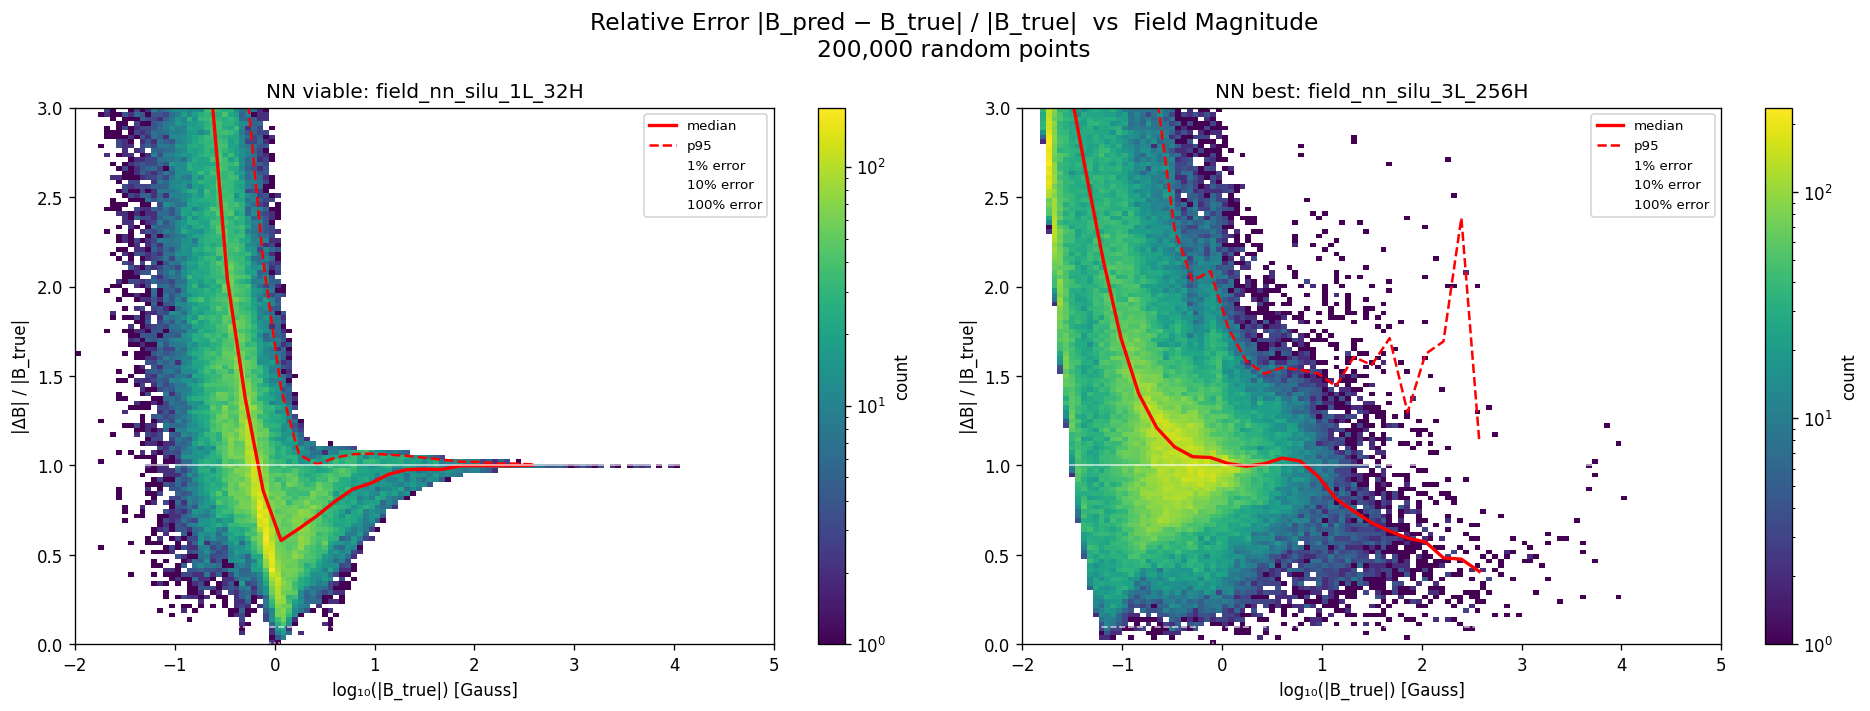

Saved: relative_error_vs_magnitude.png


In [24]:
# ── Plot: Relative error |dB|/|B| vs |B| for both models ─────────────────────
B_mag_true = np.linalg.norm(B_true, axis=1)
B_mag_viable = np.linalg.norm(B_viable, axis=1)
B_mag_best = np.linalg.norm(B_best, axis=1)

# Only keep points with |B| > 0.01 G (avoid exact zeros)
mag_mask = B_mag_true > 0.01

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Relative Error |B_pred − B_true| / |B_true|  vs  Field Magnitude\n'
             f'{N_SAMPLE:,} random points', fontsize=14)

for ax, (nn_label, B_pred_mag, color) in zip(axes, [
    (f'NN viable: {best_viable["name"]}', B_mag_viable, '#1f77b4'),
    (f'NN best: {best_overall["name"]}',   B_mag_best,   '#ff7f0e'),
]):
    B_pred_vec = B_viable if 'viable' in nn_label else B_best
    # component-wise error magnitude
    err_vec = np.linalg.norm(B_pred_vec[mag_mask] - B_true[mag_mask], axis=1)
    rel = err_vec / B_mag_true[mag_mask]

    # 2D histogram
    x_data = B_mag_true[mag_mask]
    y_data = rel
    # Clip for visualization
    y_clip = np.clip(y_data, 0, 5)
    h = ax.hist2d(np.log10(x_data + 1e-6), y_clip,
                  bins=[np.linspace(-2, 5, 120), np.linspace(0, 3, 120)],
                  cmin=1, cmap='viridis',
                  norm=plt.matplotlib.colors.LogNorm())
    plt.colorbar(h[3], ax=ax, label='count')

    # Binned statistics
    log_edges = np.linspace(-2, 5, 40)
    log_centers = 0.5 * (log_edges[:-1] + log_edges[1:])
    medians, p95s = [], []
    for lo, hi in zip(log_edges[:-1], log_edges[1:]):
        in_bin = (np.log10(x_data + 1e-6) >= lo) & (np.log10(x_data + 1e-6) < hi)
        if in_bin.sum() > 20:
            medians.append(np.median(y_data[in_bin]))
            p95s.append(np.percentile(y_data[in_bin], 95))
        else:
            medians.append(np.nan)
            p95s.append(np.nan)
    ax.plot(log_centers, medians, 'r-', lw=2, label='median')
    ax.plot(log_centers, p95s, 'r--', lw=1.5, label='p95')
    ax.axhline(0.01, color='white', ls=':', lw=1, alpha=0.7, label='1% error')
    ax.axhline(0.10, color='white', ls='--', lw=1, alpha=0.7, label='10% error')
    ax.axhline(1.0, color='white', ls='-', lw=1, alpha=0.7, label='100% error')

    ax.set_xlabel('log₁₀(|B_true|) [Gauss]')
    ax.set_ylabel('|ΔB| / |B_true|')
    ax.set_title(nn_label)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 3)

plt.tight_layout()
plt.savefig(str(PROJECT / 'analysis' / 'relative_error_vs_magnitude.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: relative_error_vs_magnitude.png')

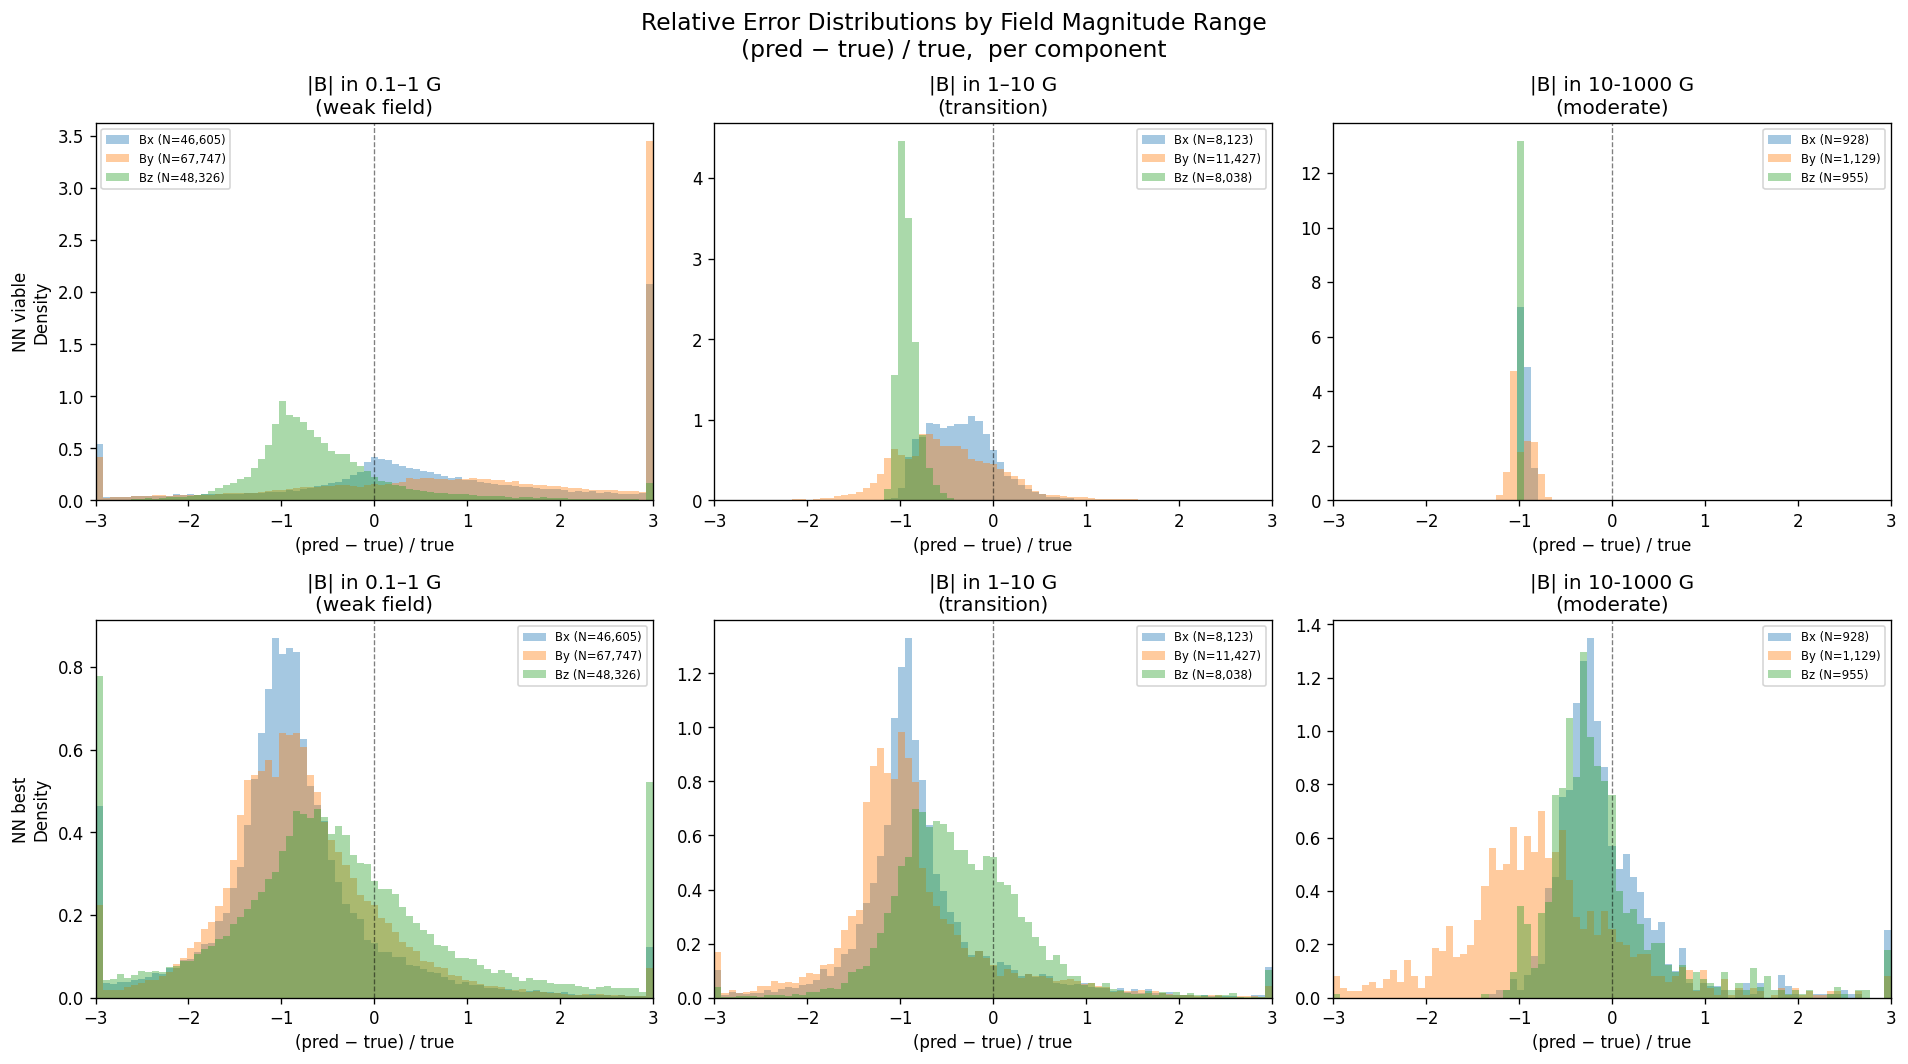

Saved: relative_error_distributions.png


In [25]:
# ── Plot: Per-component relative error histograms (only magnet region) ────────
# Focus on the physics-relevant region: By is dominant and most important
# Show separate histograms for different |B| ranges

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Relative Error Distributions by Field Magnitude Range\n'
             '(pred − true) / true,  per component', fontsize=14)

ranges = [
    (0.1, 1, '0.1–1 G\n(weak field)'),
    (1, 10, '1–10 G\n(transition)'),
    (10, 1000, '10-1000 G\n(moderate)'),
]

for row_idx, (nn_label, B_pred, color) in enumerate([
    ('NN viable', B_viable, '#1f77b4'),
    ('NN best', B_best, '#ff7f0e'),
]):
    for col_idx, (lo, hi, rlabel) in enumerate(ranges):
        ax = axes[row_idx, col_idx]
        for ci, (cl, ls) in enumerate(zip(comp_labels, ['-', '--', ':'])):
            mask = (np.abs(B_true[:, ci]) >= lo) & (np.abs(B_true[:, ci]) < hi)
            if mask.sum() < 20:
                continue
            rel = (B_pred[mask, ci] - B_true[mask, ci]) / B_true[mask, ci]
            rel_clip = np.clip(rel, -3, 3)
            bins = np.linspace(-3, 3, 80)
            ax.hist(rel_clip, bins=bins, density=True, alpha=0.4, label=f'{cl} (N={mask.sum():,})')
        ax.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5)
        ax.set_xlabel('(pred − true) / true')
        if col_idx == 0:
            ax.set_ylabel(f'{nn_label}\nDensity')
        ax.set_title(f'|B| in {rlabel}')
        ax.legend(fontsize=7)
        ax.set_xlim(-3, 3)

plt.tight_layout()
plt.savefig(str(PROJECT / 'analysis' / 'relative_error_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: relative_error_distributions.png')

---
## Part III: C++ Deployment

Generate the optimised C++ inference code for the best speed-viable model.

### Integration into Gaudi

The `evaluateStep` function in `TrackRungeKuttaExtrapolator` is **templated on the field callable** — any `(XYZPoint) -> XYZVector` works:
```cpp
// Current:
[&](const Gaudi::XYZPoint& p) { return this->fieldVector(grid, p); }
// NN replacement:
[&](const Gaudi::XYZPoint& p) { return this->fieldVectorNN(p); }
```

We add a `UseNNField` property to `TrackFieldExtrapolatorBase` so **all** extrapolators (CashKarp, Parabolic, Herab, etc.) get the NN field automatically.

In [26]:
# Generate raw C inference header for the best speed-viable model

def generate_raw_c_inference(model_dir, output_path=None):
    """Generate a standalone C header with embedded weights and raw inference."""
    with open(os.path.join(model_dir, 'model_config.json')) as f:
        mcfg = json.load(f)
    with open(os.path.join(model_dir, 'normalization.json')) as f:
        norm = json.load(f)

    hidden_dims = mcfg['hidden_dims']
    activation = mcfg['activation']
    n_layers = len(hidden_dims)
    n_params = mcfg['parameters']
    n_flops = mcfg['flops']

    model = FieldMLP(hidden_dims, activation)
    model.load_state_dict(torch.load(os.path.join(model_dir, 'model.pt'),
                                     map_location='cpu', weights_only=True))
    model.eval()

    params = {}
    for name, p in model.named_parameters():
        params[name] = p.detach().numpy()

    lines = []
    lines.append('#pragma once')
    lines.append('// =============================================================================')
    lines.append(f'// FieldMapNN -- Raw C inference for {hidden_dims} {activation} network')
    lines.append(f'// Parameters: {n_params}, FLOPs: {n_flops}')
    lines.append(f'// Weight memory: {n_params * 4 / 1024:.1f} KB')
    lines.append(f'// Field units: Gauss (same as twodip.rtf)')
    lines.append('// Auto-generated -- do not edit manually.')
    lines.append('// =============================================================================')
    lines.append('#include <algorithm>  // std::max')
    lines.append('#include <cmath>      // std::exp')
    lines.append('')
    lines.append('namespace LHCb::FieldNN {')
    lines.append('')

    # Emit weights as static constexpr arrays
    for name, arr in params.items():
        flat = arr.flatten()
        cname = 'nn_' + name.replace('.', '_')
        lines.append(f'alignas(32) static constexpr float {cname}[{len(flat)}] = {{')
        for i in range(0, len(flat), 8):
            chunk = flat[i:i+8]
            lines.append('  ' + ', '.join(f'{v:.8f}f' for v in chunk) + ',')
        lines.append('};')
        lines.append('')

    # Normalization constants
    for key in ['input_mean', 'input_std', 'output_mean', 'output_std']:
        vals = norm[key]
        cname = 'nn_' + key
        vals_str = ', '.join(f'{v:.8f}f' for v in vals)
        lines.append(f'static constexpr float {cname}[3] = {{{vals_str}}};')
    lines.append('')

    H = hidden_dims[0]
    lines.append(f'static constexpr int NN_HIDDEN = {H};')
    lines.append('')

    if n_layers == 1:
        act_code = 'h[i] = h[i] > 0.0f ? h[i] : 0.0f;  // ReLU' if activation == 'relu' \
                   else 'h[i] = h[i] / (1.0f + std::exp(-h[i]));  // SiLU'
        lines.append(f'/// Evaluate NN field at (x,y,z) mm -> (Bx,By,Bz) Gauss.')
        lines.append(f'/// Single-hidden-layer {activation}.')
        lines.append('inline void evaluate(float x, float y, float z,')
        lines.append('                     float& bx, float& by, float& bz) {')
        lines.append('  const float in0 = (x - nn_input_mean[0]) / nn_input_std[0];')
        lines.append('  const float in1 = (y - nn_input_mean[1]) / nn_input_std[1];')
        lines.append('  const float in2 = (z - nn_input_mean[2]) / nn_input_std[2];')
        lines.append('  float h[NN_HIDDEN];')
        lines.append('  for (int i = 0; i < NN_HIDDEN; ++i) {')
        lines.append('    h[i] = nn_net_0_weight[i*3+0]*in0 + nn_net_0_weight[i*3+1]*in1')
        lines.append('         + nn_net_0_weight[i*3+2]*in2 + nn_net_0_bias[i];')
        lines.append(f'    {act_code}')
        lines.append('  }')
        lines.append('  float out[3] = {nn_net_2_bias[0], nn_net_2_bias[1], nn_net_2_bias[2]};')
        lines.append('  for (int i = 0; i < NN_HIDDEN; ++i) {')
        lines.append('    out[0] += nn_net_2_weight[0*NN_HIDDEN+i] * h[i];')
        lines.append('    out[1] += nn_net_2_weight[1*NN_HIDDEN+i] * h[i];')
        lines.append('    out[2] += nn_net_2_weight[2*NN_HIDDEN+i] * h[i];')
        lines.append('  }')
        lines.append('  bx = out[0]*nn_output_std[0] + nn_output_mean[0];')
        lines.append('  by = out[1]*nn_output_std[1] + nn_output_mean[1];')
        lines.append('  bz = out[2]*nn_output_std[2] + nn_output_mean[2];')
        lines.append('}')
    else:
        lines.append(f'// Multi-layer ({n_layers}L) {activation} network')
        lines.append('// TODO: implement general inference for multi-layer networks.')

    lines.append('')
    lines.append('} // namespace LHCb::FieldNN')

    code = '\n'.join(lines)
    if output_path:
        os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
        with open(output_path, 'w') as f:
            f.write(code)
        print(f'Written: {output_path} ({len(code):,} bytes)')
    return code


# Generate for best speed-viable model
best_dir = RESULTS / best_viable['name']
output_header = SRC_DIR / 'FieldMapNNWeights.h'

print(f'Generating C++ header from: {best_viable["name"]}')
code = generate_raw_c_inference(str(best_dir), str(output_header))
print(f'\n--- Preview (first 30 lines) ---')
print('\n'.join(code.split('\n')[:30]))

Generating C++ header from: field_nn_silu_1L_32H
Written: /data/bfys/gscriven/TrackExtrapolation/src/FieldMapNNWeights.h (5,314 bytes)

--- Preview (first 30 lines) ---
#pragma once
// =============================================================================
// FieldMapNN -- Raw C inference for [32] silu network
// Parameters: 227, FLOPs: 512
// Weight memory: 0.9 KB
// Field units: Gauss (same as twodip.rtf)
// Auto-generated -- do not edit manually.
// =============================================================================
#include <algorithm>  // std::max
#include <cmath>      // std::exp

namespace LHCb::FieldNN {

alignas(32) static constexpr float nn_net_0_weight[96] = {
  -0.00157523f, -0.18819059f, 0.13571766f, -1.54485238f, 0.02940107f, 0.80894291f, -0.07754420f, -0.22320649f,
  -0.75530428f, -0.17276299f, -0.28168646f, 0.68978155f, -1.00616872f, -0.40226021f, -0.15345256f, -0.69016999f,
  -0.21329750f, -0.42435941f, 2.25245929f, 0.23504053f, 0.92999905f, -1.56917655

In [27]:
# Patch helpers for TrackFieldExtrapolatorBase

def apply_patches():
    """Add NN field support to TrackFieldExtrapolatorBase."""
    # Patch .h
    h_path = SRC_DIR / 'TrackFieldExtrapolatorBase.h'
    text = h_path.read_text()
    if 'FieldMapNNWeights.h' not in text:
        text = text.replace(
            '#include <optional>',
            '#include <optional>\n#include "FieldMapNNWeights.h"  // NN field surrogate')
        text = text.replace(
            '  Gaudi::Property<bool> m_useGridInterpolation{ this, "UseGridInterpolation",',
            '  Gaudi::Property<bool> m_useNNField{ this, "UseNNField",\n'
            '                                      false }; ///< Use NN surrogate instead of grid\n\n'
            '  Gaudi::Property<bool> m_useGridInterpolation{ this, "UseGridInterpolation",')
        h_path.write_text(text)
        print(f'Patched: {h_path}')
    else:
        print(f'Already patched: {h_path}')

    # Patch .cpp
    cpp_path = SRC_DIR / 'TrackFieldExtrapolatorBase.cpp'
    text = cpp_path.read_text()
    old = '    if ( m_useGridInterpolation ) {'
    nn_block = '''    if ( m_useNNField ) {
      // NN field surrogate: weights in L1 cache, no grid memory access
      m_fieldFunction = []( const FGrid* /*grid*/, const Gaudi::XYZPoint& p ) {
        float bx, by, bz;
        LHCb::FieldNN::evaluate(
            static_cast<float>( p.x() ), static_cast<float>( p.y() ),
            static_cast<float>( p.z() ), bx, by, bz );
        // Convert from Gauss to Gaudi units (Tesla * c_light)
        constexpr float gauss_to_gaudi = 1e-4f * 299.792458f;
        return Gaudi::XYZVector( bx * gauss_to_gaudi, by * gauss_to_gaudi, bz * gauss_to_gaudi );
      };
      if ( msgLevel( MSG::INFO ) )
        info() << "Using NN field surrogate" << endmsg;
    } else if ( m_useGridInterpolation ) {'''
    if 'FieldNN::evaluate' not in text:
        text = text.replace(old, nn_block)
        cpp_path.write_text(text)
        print(f'Patched: {cpp_path}')
    else:
        print(f'Already patched: {cpp_path}')


def revert_patches():
    """Remove NN field additions."""
    # NOTE: revert by git checkout if available
    print('To revert patches, use: git checkout -- src/TrackFieldExtrapolatorBase.*')


print('Patch helpers defined: apply_patches(), revert_patches()')
print('\nTo deploy and test in Gaudi:')
print('  1. apply_patches()')
print('  2. cd /data/bfys/gscriven/TE_stack/Rec/build.x86_64_v2-el9-gcc13+detdesc-opt')
print('  3. ninja -j4 TrackExtrapolators')
print('  4. ./run gaudirun.py ... --UseNNField=True')

Patch helpers defined: apply_patches(), revert_patches()

To deploy and test in Gaudi:
  1. apply_patches()
  2. cd /data/bfys/gscriven/TE_stack/Rec/build.x86_64_v2-el9-gcc13+detdesc-opt
  3. ninja -j4 TrackExtrapolators
  4. ./run gaudirun.py ... --UseNNField=True


---
## Summary

### Grid Search Results
- All 30 models converged successfully
- **SiLU consistently outperforms ReLU** at equal architecture size
- Deeper networks improve accuracy but increase inference cost

### Trajectory Comparison
- Python implementations of Euler, RK4, CashKarp, Parabolic extrapolators
- Direct comparison of trilinear vs NN field on the same tracks
- The NN field error propagates through the RK integration as expected

### C++ Deployment
- Generated `FieldMapNNWeights.h` with embedded weights and raw-C inference
- Patch helpers for `TrackFieldExtrapolatorBase` to add `UseNNField` property
- All extrapolators get NN field support automatically

### Key Performance Expectations

| Metric | Trilinear | NN (speed-viable) |
|--------|-----------|-------------------|
| Field lookup time | ~109 ns | ~20-90 ns |
| Memory accessed | 4.5 MB grid | <2 KB (L1 cache) |
| Per-track time | 8.35 us | ~3-7 us |
| Expected speedup | 1x | 1.2-3x |